# **Instacart Customer Segmentation & Behavioral Analysis**

### <u>**Executive Summary** </u>
This analysis moves beyond aggregate metrics to identify meaningful differences in customer purchasing behavior through exploratory analysis and rule-based behavioral segmentation. By examining who customers are and when and how they shop, we can identify opportunities to support more personalized customer experiences and translate raw transactional data into targeted merchandising and personalization strategies tailored to each customer group.

#### <font color='darkgreen'> <u> **Key Findings:** </u></font> 
- **Consistent Shoppers Drive Disproportionate Spend:** Representing only **6.81%** of customers, this segment generates **21.04%** of total estimated spend, demonstrating that customer share alone, does not equate to business value.
- **Hour- and day-level trends reveal specific shopping behaviors:** 
    - **Evening (6–11:59 PM):** Frozen desserts heavily over-index, coinciding with a distinct **10 PM peak** in average spend.
    - **Overnight (12–5 AM):** Orders are centered around grocery staples like produce, dairy, and water.
    - **Friday Shift:** Fridays exhibit elevated spending and larger basket sizes as customers prepare for the weekend.
- **Basket Composition Differs Across Spending Tiers:** Spending tiers differ not only in order value, but in *what* customers buy. Premium spenders build larger, multi-category baskets, whereas Low Spend customers build smaller baskets focused on everyday essentials.
- **Light Shoppers Represent a Growth Opportunity:** This segment accounts for **7.01%** of customers but only **0.52% of estimated spend**. Their purchasing behavior centers on everyday essentials, highlighting an opportunity to encourage repeat purchasing through habit-building and re-engagement strategies.
- **Demographics Show Limited Association with Product Behavior:** Age and household type show minimal variation in department-level purchasing, while income has only a limited relationship with spending behavior. Observed product preferences appear to be more closely associated with **behavioral characteristics** than demographic attributes.
- **Product Demand Shifts Across Time:** Lift analysis shows that certain products over‑index at specific hours and days, reinforcing the potential value of **time-sensitive product recommendations**.
- **Behavioral Insights Enable More Targeted Strategies:** Combining customer segments with temporal and product-level insights can help identify **when, what, and how to engage different customer groups,** creating opportunities for more relevant recommendations and personalized customer experiences.

---

### <u>**Data Sources & Analytical Approach**</u>
***This analysis uses two cleaned datasets prepared during the data-integration phase, along with additional order-level and user-level tables engineered within this notebook.***

- **Order–Product Dataset:** 
Contains one row per product purchased within each order and provides the foundation for analyzing purchasing and order-level behavior. Key fields include `order_id`, `product_id`, and order‑level timing fields such as `order_hour_of_day`, `order_dow`, and `days_since_prior_order`.
- **Merged Product‑Level Dataset:** 
Combines product information, including names, departments, aisles, and prices, with order-level attributes to support product-level purchasing analysis. Records with missing product information were removed during data preparation, so row counts may differ from the original orders data.

- **Engineered Order‑Level and User‑Level Tables:**
The two datasets above are used to construct additional tables that aggregate purchasing behavior at the order level (`total_spend`, `basket_size`, etc.) and user-level (`order_freq_status`, `engagement_status`, etc.). These engineered features form the basis for the rule-based customer segmentation.

#### <font color='cornflowerblue'> <u>**Analytical Approach**</u> </font> 
This analysis combines descriptive analytics with rule-based customer segmentation to understand both **customer-level behavioral patterns (segments)** and **contextual shopping insights (micro-behaviors)**. Customer behavior is evaluated across four core dimensions, supported by product-level lift analysis:<br>

**1. Temporal Patterns**</br>
**2. Order Frequency** </br>
**3. Basket Size** </br>
**4. Spending Behavior** </br>
**5. Product & Behavioral Lift Analysis** </br>

*Rather than using unsupervised clustering, customer segments are defined using **interpretable behavioral thresholds** designed for business usability. This approach allows each segment to be clearly understood, linked to specific customer behaviors, and translated into potential engagement strategies.*

---

### <u>**Key Business Questions Answered**</u>
This notebook delivers data-driven insights to answer the following strategic questions:
-  **When** do customers shop?
    - Day-of-week, hour-of-day, and time between orders.
- **How** do customers shop? 
    - Order frequency, basket size, and spending behavior.
- **What** are customers buying?
    - Product price distribution, price-tier classification, department preferences, and product lift analysis.
- **Who** are the customers?
    - Demographic characteristics including age, income, number of dependents, and family status.
    - Rule-based customer segments based on purchasing behavior and customer attributes.
- **Which** customers generate the greatest business value?
    - Estimated spend and customer value contribution across behavioral segments.
- **Where** do opportunities exist to improve customer engagement?
   - Segment-specific recommendations informed by behavioral patterns and shopping missions.
  
---

### <u>**Notebook Roadmap**</u> 
The notebook is structured as follows:
*   **Part 1: <font color='#442202'>Temporal Patterns (When)</font>** 
*   **Part 2: <font color='#003d29'>Order & Spend Behavior (How)</font>** 
*   **Part 3: <font color='#ff7009'>Product Behavior (What)</font>**
*   **Part 4: <font color='palevioletred'>Customer Demographics (Who)</font>** 
*   **Part 5: <font color='rebeccapurple'>User-Level Feature Engineering</font>** 
*   **Part 6: <font color='crimson'>Rule-Based Customer Segmentation</font>**  
*   **Part 7: <font color='#85cc3e'>Strategic Recommendations & Behavioral Opportunities (Which & Where)</font>** 
*   **Part 8: <font color='darkblue'>Business Takeaways, Limitations, and Future Analytical Work</font>**


### Importing Libraries and Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Importing datasets and creating a path to project folder. 
path = r'C:\Users\TanaT\Portfolio Projects\Instacart - Customer Segementation & Behavioral Analysis'

# Order data (at the order_id level)
df_orders_clean = pd.read_pickle(os.path.join(path, '02 Data', '02 Processed Data',  'orders_cleaned.pkl'))

# Clean merge no nulls (for analysis)
df_clean = pd.read_pickle(os.path.join(path, '02 Data', '02 Processed Data', 'merged_data_clean.pkl'))

## <div style = 'background-color: #efe1cf'> <center> <font color='#442202'>**1. Temporal Patterns: When Do Customers Shop?**</font> </div>
This section analyzes customer **purchasing patterns across days of the week, hours of the day, and time between orders**. These findings establish a baseline understanding of customer routines and highlight key periods of activity that may represent different shopping behaviors.

In [3]:
# Overview of the orders data - at the order_id level 
df_orders_clean.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order
0,2539329,1,1,Monday,8,NaN,True
1,2398795,1,2,Tuesday,7,15.0,False
2,473747,1,3,Tuesday,12,21.0,False
3,2254736,1,4,Wednesday,7,29.0,False
4,431534,1,5,Wednesday,15,28.0,False


In [4]:
df_orders_clean.shape

(3421083, 7)

In [5]:
# Number of unique orders should be the number of rows (3421083)
df_orders_clean['order_id'].nunique()

3421083

### Order Volume by Day

#### Raw Counts of Orders

In [6]:
orders_dow  = df_orders_clean.groupby('order_dow', observed=True)['order_id'].count()
print(orders_dow)

order_dow
Saturday     600905
Sunday       587478
Monday       467260
Tuesday      436972
Wednesday    426339
Thursday     453368
Friday       448761
Name: order_id, dtype: int64


#### Proportion of Orders

In [7]:
# Percentage of total orders by day.
orders_dow_percent = orders_dow / orders_dow.sum() * 100 
print(orders_dow_percent)

order_dow
Saturday     17.564759
Sunday       17.172281
Monday       13.658248
Tuesday      12.772914
Wednesday    12.462106
Thursday     13.252178
Friday       13.117513
Name: order_id, dtype: float64


### **Busiest Days of the Week**

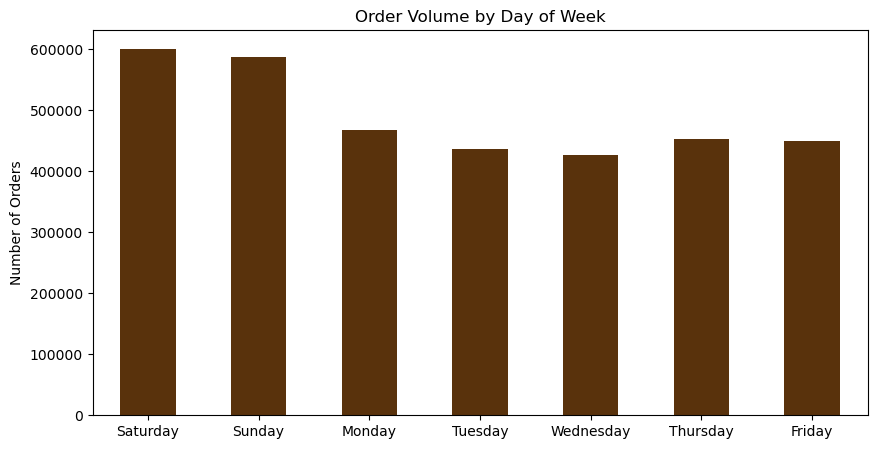

In [8]:
# Plotting count of unique orders per day.

plt.figure(figsize=(10, 5))
orders_bar = orders_dow.plot(kind='bar', color= '#59320c', rot=0)
plt.xlabel('')
plt.ylabel('Number of Orders')
plt.title('Order Volume by Day of Week')
plt.tight_layout
plt.show()

### <u> **Weekend Shopping Drives the Highest Order Volume**
- **Weekend Surge:** Order volume peaks on **Saturday and Sunday**, which together acount for approximately **34.7% of all orders**.
- **Mid-Week Lull:** **Tuesday and Wednesday** represent the lowest order volume days, each accounting for approximately **12% of orders**.
- **Weekday Stability:** The rest of the week shows relatively stable order volume, with each day contributing approximately **13%–14% of total orders**.

> *Order volume alone does not indicate whether customers are completing larger grocery trips or smaller convenience purchases. Basket size and purchasing behavior will be analyzed in later sections to better understand the shopping missions behind these orders.*

In [9]:
# Exporting visual
orders_bar.figure.savefig(os.path.join(path, '04 Insights & Visualizations', 'bar_count_of_orders_dow.png'), dpi=300, bbox_inches='tight')

---

### Order Volume by Hour of Day

#### Raw Counts

In [10]:
# Number of unique orders per hour - raw counts
orders_hour = df_orders_clean.groupby('order_hour_of_day')['order_id'].count()
print(orders_hour)

order_hour_of_day
0      22758
1      12398
2       7539
3       5474
4       5527
5       9569
6      30529
7      91868
8     178201
9     257812
10    288418
11    284728
12    272841
13    277999
14    283042
15    283639
16    272553
17    228795
18    182912
19    140569
20    104292
21     78109
22     61468
23     40043
Name: order_id, dtype: int64


#### Proportion

In [11]:
# Percentage of orders per hour. 
orders_hour_percent = orders_hour / orders_hour.sum() * 100 
print(orders_hour_percent)

order_hour_of_day
0     0.665228
1     0.362400
2     0.220369
3     0.160008
4     0.161557
5     0.279707
6     0.892378
7     2.685348
8     5.208906
9     7.535976
10    8.430605
11    8.322745
12    7.975282
13    8.126052
14    8.273462
15    8.290913
16    7.966863
17    6.687794
18    5.346611
19    4.108904
20    3.048508
21    2.283166
22    1.796741
23    1.170477
Name: order_id, dtype: float64


### **Busiest Hours of the Day** 

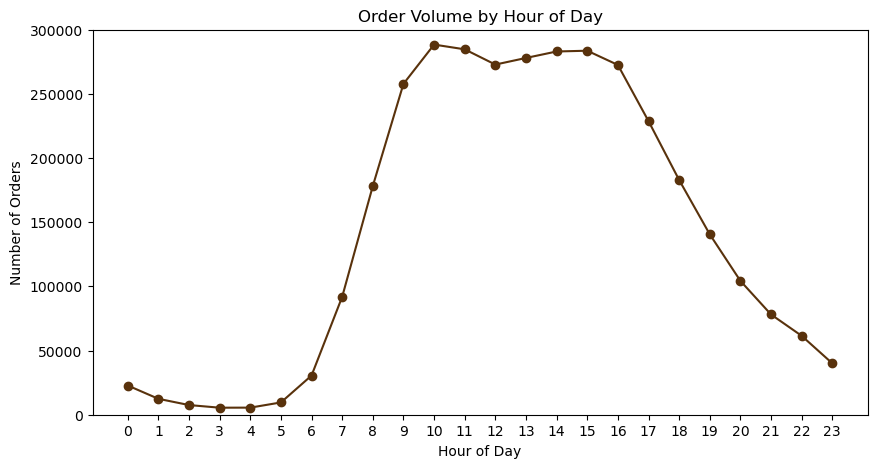

In [12]:
# Plotting the number of unique orders throughout the day/24 hr period as a line graph.

orders_hour_bar = orders_hour.plot(kind='line', figsize=(10, 5), marker='o', color='#59320c')

plt.xlabel('Hour of Day')
plt.xticks(range(0, 24)) # Ensures every hour is labeled
plt.ylabel('Number of Orders')
plt.title('Order Volume by Hour of Day')
plt.xticks(range(0, 24)) # Ensures every hour is labeled
plt.ylim(0, 300000)
plt.tight_layout
plt.show()

### <u> **Order Volume is Concentrated During Daytime Hours**
- **Overnight Low Activity:** Order volume is lowest between **12:00 AM and 5:00 AM**, representing less than 2% of total daily activity.
- **Morning Growth:** Activity increases **beginning around 6:00 AM**, reaching a peak around **10:00 AM.**
- **Core Shopping Window:** Order volume remains consistently high between approximately **10:00 AM and 3:00 PM**, accounting for nearly half of all daily orders **(~49.4%)**.
- **Evening Decline:** Order activity gradually decreases **after 4:00 PM**, continuing through late evening and overnight hours.

In [13]:
# Exporting visual
orders_hour_bar.figure.savefig(os.path.join(path, '04 Insights & Visualizations', 'bar_count_of_orders_hour.png'), dpi=300, bbox_inches='tight')

---

### **Heatmap of Peak Order Activity**

In [14]:
# 1. Grouping by both day and hour and counting unique orders.
heatmap = (df_orders_clean.groupby(['order_dow', 'order_hour_of_day'], observed=True).size())

In [15]:
# 2. Reshaping data into a grid (days as rows, hours as columns).
heatmap_matrix = heatmap.unstack(fill_value=0)

In [16]:
# Heatmap
heatmap_matrix = (
    df_orders_clean
    .groupby(['order_dow', 'order_hour_of_day'], observed=True)['order_id']
    .nunique()
    .unstack()
)

In [17]:
heatmap_matrix

order_hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
order_dow,,,,,,,,,,,,,,,,,,,,,
Saturday,3936,2398,1409,963,813,1168,3329,12410,28108,40798,...,54552,53954,49463,39753,29572,22654,18277,14423,11246,6887
Sunday,3674,1830,1105,748,809,1607,5370,16571,34116,51908,...,46764,46403,44761,36792,28977,22145,16281,11943,8992,5620
Monday,3059,1572,943,719,744,1399,4758,13245,24635,36314,...,37173,37469,37541,32151,26470,20084,15039,10653,8146,5358
Tuesday,2952,1495,953,654,719,1355,4562,12396,22553,32312,...,34773,35990,35273,30368,25001,19249,13795,10278,8242,5181
Wednesday,2642,1512,899,686,730,1330,4401,12493,21814,31409,...,33625,34222,34093,29378,24425,19350,14186,10796,8812,5645
Thursday,3189,1672,1016,841,910,1574,4866,13434,24015,34232,...,37407,37508,35860,29955,24310,18741,13322,9515,7498,5265
Friday,3306,1919,1214,863,802,1136,3243,11319,22960,30839,...,38748,38093,35562,30398,24157,18346,13392,10501,8532,6087


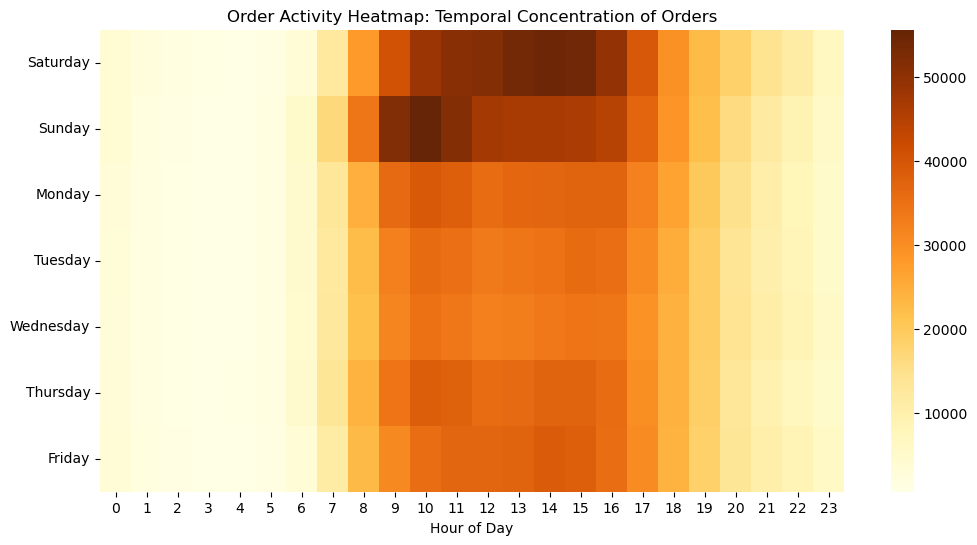

In [18]:
# 3. Creating the heatmap. 
heatmap_plot = plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_matrix, cmap='YlOrBr')
plt.title('Order Activity Heatmap: Temporal Concentration of Orders')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.show()

### <u>**Peak Shopping Windows Shift Throughout the Week**
- **Weekend Peak Shift:** Saturday order volume reaches its highest concentration in the early afternoon (**1–3 PM**), whereas Sunday shopping shifts significantly earlier, peaking in the morning (**9–11 AM**).
- **Consistent Weekday Core Window:** Weekday activity displays a stable, uniform cluster between **9 AM and 4 PM**, with lower overall volume compared to weekend peaks.
- **Off-Peak Decline:** Across all seven days, order density begins a steady decline around **4 PM**, reaching its lowest levels during the overnight hours (**12 AM–6 AM**).

In [19]:
# Exporting visual
heatmap_plot.figure.savefig(os.path.join(path, '04 Insights & Visualizations', 'order_density_heatmap.png'), dpi=300, bbox_inches='tight')

---

####  Time Blocks: Creating 6 hour time blocks to categorize periods of the day.


In [20]:
# Breaking the day into 6 hour periods (4 time blocks) - defining the function
def time_block(order_hour):
    if 0 <= order_hour < 6:
        return 'Overnight'
    elif 6 <= order_hour < 12:
        return 'Morning'
    elif 12 <= order_hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

# Creating a new column for the time blocks an applying the function. 
df_orders_clean['time_block'] = df_orders_clean['order_hour_of_day'].apply(time_block)

In [21]:
# Checking new column in dataframe. 
df_orders_clean.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order,time_block
0,2539329,1,1,Monday,8,NaN,True,Morning
1,2398795,1,2,Tuesday,7,15.0,False,Morning
2,473747,1,3,Tuesday,12,21.0,False,Afternoon
3,2254736,1,4,Wednesday,7,29.0,False,Morning
4,431534,1,5,Wednesday,15,28.0,False,Afternoon


In [22]:
# Converting the column into an categorical column to save memory.
df_orders_clean['time_block'] = df_orders_clean['time_block'].astype('category')

In [23]:
# Checking dtypes. 
df_orders_clean.dtypes

order_id                     int64
user_id                      int64
order_number                 int64
order_dow                 category
order_hour_of_day            int64
days_since_prior_order     float64
is_first_order                bool
time_block                category
dtype: object

In [24]:
# Count of flags - checking all orders flagged
time_blocks_count = df_orders_clean['time_block'].value_counts(dropna=False)
print(time_blocks_count)

time_block
Afternoon    1618869
Morning      1131556
Evening       607393
Overnight      63265
Name: count, dtype: int64


#### Orders Volume per Time Block

In [25]:
# Raw counts of ORDERS per time block. 
orders_by_block = df_orders_clean.groupby('time_block', observed=True)['order_id'].count()
print(orders_by_block)

time_block
Afternoon    1618869
Evening       607393
Morning      1131556
Overnight      63265
Name: order_id, dtype: int64


In [26]:
# Convert counts into percentages.
orders_block_percent = (orders_by_block / orders_by_block.sum()) * 100
print(orders_block_percent)

time_block
Afternoon    47.320366
Evening      17.754407
Morning      33.075959
Overnight     1.849268
Name: order_id, dtype: float64


### <u>**Approximately 80% of Orders Are Placed During Morning and Afternoon Hours** </u>
Order activity is heavily concentrated during daytime hours, with **morning and afternoon periods (6 AM - 5 PM)** accounting for approximately **80% of all orders**. However, later hours (evening and overnight) and lower-volume windows may represent distinct shopping missions rather than simply reduced engagement. 

> *Later sections examine how purchasing behavior differs across time periods.*

### Order Cadence
This is calculated using the `days_since_prior_order` column at the order-level to measure the average and median time between customer orders.

In [27]:
# Order frequency 
order_freq = df_orders_clean[['order_id', 'days_since_prior_order']]

In [28]:
# 2. Calculating the average time between orders. 
avg_days_between_orders = order_freq['days_since_prior_order'].mean()
print(f"Average time between orders: {avg_days_between_orders:.2f} days")

Average time between orders: 11.11 days


In [29]:
median_days_between_orders = order_freq['days_since_prior_order'].median()
print(f"Median time between orders: {median_days_between_orders:.2f} days")

Median time between orders: 7.00 days


### <u>**Order Cadence Reveals a Weekly Shopping Pattern** </u>
- Customers typically place an subsequent order every 7 days **(median days between orders = 7 days)**, suggesting a consistent weekly shopping pattern.
- The **average time between orders is higher (11.11 days)** than the median, indicating that some customers have substantially longer gaps between purchases, pulling the average upward. Since the distribution is right-skewed, the **median provides a more representative view of typical shopping behavior.**

> ***Together, these temporal patterns reveal when customers shop and how frequently they return. The following sections examine how these shopping behaviors translate into order size, spending patterns, and customer value.***

---

## <div style = 'background-color: #3a682f'> <center> <font color='#faf1e5'> **2. Order & Spend Behavior: How Do Customers Shop?**</font> </div>
This section examines how customers shop by analyzing **basket size**, **order value**, and **spending patterns** at the **order-level**. By understanding the typical size and value of shopping trips, this analysis identifies differences in purchasing behavior and provides context for later customer segmentation and product-level analysis.

### Basket Size

In [30]:
# Making a subset of product data to work with.
product_data = df_clean[['order_id', 'product_id', 'product_name', 'department']]

In [31]:
# Counting the number of products in each order (product-level data).
product_data = product_data.copy()
product_data['order_total_items'] = product_data.groupby('order_id')['product_id'].transform('count')

In [32]:
product_data.head()

,order_id,product_id,product_name,department,order_total_items
0,2,33120,Organic Egg Whites,dairy eggs,9
1,2,28985,Michigan Organic Kale,produce,9
2,2,9327,Garlic Powder,pantry,9
3,2,45918,Coconut Butter,pantry,9
4,2,30035,Natural Sweetener,pantry,9


In [33]:
# Dropping duplicate orders so every unique receipt is only counted ONCE.
unique_baskets = product_data[['order_id', 'order_total_items']].drop_duplicates(subset=['order_id'])

In [34]:
avg_basket_size = unique_baskets['order_total_items'].mean()
print(f"Average Basket Size: {avg_basket_size.round(2)} items")

Average Basket Size: 10.08 items


In [35]:
median_basket_size = unique_baskets['order_total_items'].median()
print(f"Median Basket Size: {median_basket_size} items")

Median Basket Size: 8.0 items


#### Distribution of Basket Size

In [36]:
# Using the 1 value per order variable to check distribution. 
unique_baskets['order_total_items'].describe()

count    3.214668e+06
mean     1.007854e+01
std      7.518427e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: order_total_items, dtype: float64

### <u> **Core Shopping Behavior Leans Toward Smaller Baskets** </u>
Customers typically purchase **8 items per order (median)**, while the **average basket contains 10.08 items**, reflecting a **right-skewed distribution** that is driven by a minority of unusually large orders. As a result, the **median is a more accurate representation of typical basket behavior**.

#### Creating basket size flags to be used for customer segmentation.
A `basket_size` flag will be created based on the distribution (quartiles) of the `basket_item_count` column. 

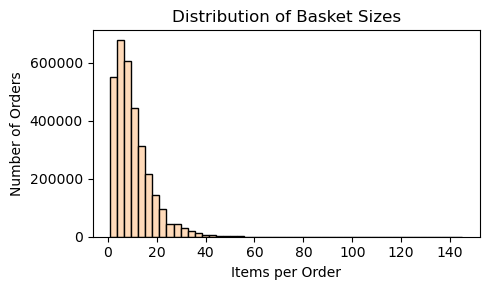

In [37]:
# Since there is a large gap between the 75th percentile and the max, I am plotting to see the distribution with a histogram to determine flag cutoffs.
plt.figure(figsize=(5,3))

basket_size_hist = plt.hist(unique_baskets['order_total_items'], bins=50, edgecolor='black', color='peachpuff')
plt.title('Distribution of Basket Sizes')
plt.xlabel('Items per Order')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

In [38]:
# Making basket size categories based on above output.
# Bottom 25th percentile (1-5 items).
unique_baskets.loc[unique_baskets['order_total_items'] <= 5, 'basket_size'] = 'small basket'

In [39]:
# Medium basket (between 25th and 75th percentile - majority of orders).
unique_baskets.loc[(unique_baskets['order_total_items'] > 5) & (unique_baskets['order_total_items'] <= 14), 'basket_size'] = 'medium basket'

In [40]:
# Large basket (high-end of distribution - between 15 and 30 items)
unique_baskets.loc[(unique_baskets['order_total_items'] > 14) & (unique_baskets['order_total_items'] <= 30), 'basket_size'] = 'large basket'

In [41]:
# Creating a fourth "bulk" cateogry where the data natually flattens based on the histogram.
unique_baskets.loc[unique_baskets['order_total_items'] > 30, 'basket_size'] = 'bulk basket'

In [42]:
# Checking that all orders were flagged.
unique_baskets.drop_duplicates('order_id')['basket_size'].value_counts(dropna=False)

basket_size
medium basket    1500457
small basket     1002556
large basket      646283
bulk basket        65372
Name: count, dtype: int64

#### Proportion of Basket Sizes

In [43]:
# Calculating the proportion of basket size flags - ORDER level (dropping dups)
basket_size_pct = unique_baskets['basket_size'].value_counts(normalize=True)*100
basket_size_pct

basket_size
medium basket    46.675333
small basket     31.186922
large basket     20.104191
bulk basket       2.033554
Name: proportion, dtype: float64

### <u>**Approximately 78% of Orders Contain 14 Items or Fewer** </u>
- **Most baskets (~46.7%) contain between 6-14 items (medium basket)**, followed by **small baskets (containing 5 items or less)**.
- Together **small and medium baskets** represent **approximately 78% of all orders**, while **bulk baskets (30+ items)** account for just **2%** of all orders.

In [44]:
# Merging the basket flag to main order df. 
df_orders_clean = df_orders_clean.merge(
    unique_baskets[['order_id', 'order_total_items', 'basket_size']],
    on='order_id',
    how='left'
)

#### Do customers buy more items depending on the time of day?
Understanding how basket size varies across `time block` helps reveal whether customers use Instacart for quick trips or larger stock‑up orders at different times of day.

In [45]:
# Basket size per time block - order volume is high in the day, are baskets also larger in the day?
basket_size_by_block = (
    df_orders_clean
    .groupby('time_block', observed=True)['order_total_items']
    .agg(['mean', 'median', 'count'])
        .sort_index()
)

basket_size_by_block

,mean,median,count
time_block,,,
Afternoon,10.039986,8.0,1519010
Evening,10.016359,8.0,569287
Morning,10.167945,8.0,1067071
Overnight,10.054317,8.0,59300


### <u> **Basket Size Remains Stable Throughout the Day** </u>
Although order volume varies considerably throughout the day, **basket size remains remarkably consistent across all time blocks**.
> ***Order volume  appears to be a differentiating factor**. **Morning and afternoon order volume is approximately 4x higher** than evening and overnight periods, however **customers consistently build baskets containing about 8 items regardless of the time of day.***

---

## <font color='#3a682f'> <u> <center>**2.2 Spend Behavior** </u> </font> 
Although basket size remains consistent across time periods, order value may differ based on product mix and purchasing behavior. This section examines **order-level spend patterns** across multiple dimensions, including **temporal variables, basket size, and purchasing behavior**.  

#### Total Spend per Order

In [53]:
# Order variables to merge over
order_variables = df_orders_clean[['order_id', 'time_block', 'order_total_items', 'basket_size']]

In [54]:
# Merging only relevant order variables over to product-level dataset
df_order_behavior = df_clean.merge(
    order_variables,
    on='order_id',
    how='left',
)

In [55]:
# Checking columns in merged dataset
df_order_behavior.columns

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id',
       'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'is_first_order', 'product_name', 'aisle_id',
       'department_id', 'price', 'department', 'gender', 'state', 'age',
       'date_joined', 'n_dependents', 'fam_status', 'income', 'merge_check',
       'time_block', 'order_total_items', 'basket_size'],
      dtype='object')

In [56]:
# 3. Calculating total order spend -  summming the prices per order to get the order-level spend
order_spend_table = (
    df_order_behavior.groupby('order_id')['price']
    .sum()
    .reset_index(name='total_order_spend')
)

In [57]:
order_spend_table.head()

,order_id,total_order_spend
0,2,91.6
1,3,70.3
2,4,92.8
3,5,210.7
4,6,27.5


In [58]:
# 4. Making a lookup map of {order_id: total_order_spend}
order_spend_map = order_spend_table.set_index('order_id')['total_order_spend']

In [59]:
# 5. Mapping the total order spend back onto the orders and products data
df_order_behavior['total_order_spend'] = df_order_behavior['order_id'].map(order_spend_map)

In [60]:
# Checking data
df_order_behavior.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order,...,age,date_joined,n_dependents,fam_status,income,merge_check,time_block,order_total_items,basket_size,total_order_spend
0,2,33120,1,True,202279,3,Thursday,9,8.0,False,...,57,2020-02-06,3,married,98119,both,Morning,9.0,medium basket,91.6
1,2,28985,2,True,202279,3,Thursday,9,8.0,False,...,57,2020-02-06,3,married,98119,both,Morning,9.0,medium basket,91.6
2,2,9327,3,False,202279,3,Thursday,9,8.0,False,...,57,2020-02-06,3,married,98119,both,Morning,9.0,medium basket,91.6
3,2,45918,4,True,202279,3,Thursday,9,8.0,False,...,57,2020-02-06,3,married,98119,both,Morning,9.0,medium basket,91.6
4,2,30035,5,False,202279,3,Thursday,9,8.0,False,...,57,2020-02-06,3,married,98119,both,Morning,9.0,medium basket,91.6


### **Order-Level Spend Distribution: What Is the Typical Value of a Shopping Trip?**
This section examines **order-level spending** to understand the typical value of a shopping trip and establish **order-level spending tiers** based on the observed distribution.

In [61]:
# Spend dist. 
order_spend_table['total_order_spend'].describe()

count    3.214668e+06
mean     7.852269e+01
std      6.004287e+01
min      1.000000e+00
25%      3.450000e+01
50%      6.430000e+01
75%      1.073000e+02
max      1.092200e+03
Name: total_order_spend, dtype: float64

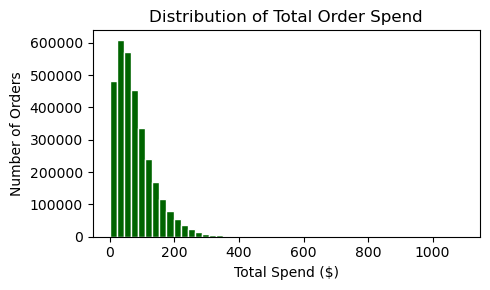

In [62]:
# Plotting dist. to determine criteria for flag creation. 
plt.figure(figsize=(5,3))

order_spend_hist = plt.hist(order_spend_table['total_order_spend'], bins=50, edgecolor='white', color='darkgreen')

plt.title('Distribution of Total Order Spend')
plt.xlabel('Total Spend ($)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

#### Total Order Spend Is Right-Skewed Toward Higher-Value Purchases
- Most orders fall between approximately **\\$34 and \\$107**, with a **median order value of \\$64.30**.
- While **75% of orders are \\$107 or less**, a small number of orders exceed $1,000, creating a right-skewed distribution and increasing the average order value.

In [63]:
# Creating flags (order value) based on dist. 
# 25th percentile
order_spend_table.loc[order_spend_table['total_order_spend'] <= 35, 'order_value'] = 'low order spend'

In [64]:
# Middle 50%
order_spend_table.loc[(order_spend_table['total_order_spend'] > 35) & (order_spend_table['total_order_spend'] <= 107), 'order_value'] = 'moderate order spend'

In [65]:
# The $200 value is a natural breakpoint for identifying unusually high‑value orders (based on the histogram).
order_spend_table.loc[(order_spend_table['total_order_spend'] > 107) & (order_spend_table['total_order_spend'] <= 200), 'order_value'] = 'high order spend'

In [66]:
# Orders above $200 fall into the top ~5% of all orders and represent the rare, high‑value tail of the distribution. 
order_spend_table.loc[order_spend_table['total_order_spend'] > 200, 'order_value'] = 'premium order spend'

In [67]:
# Checking for nulls - count of flags
order_spend_table['order_value'].value_counts(dropna=False)

order_value
moderate order spend    1589128
low order spend          818819
high order spend         659583
premium order spend      147138
Name: count, dtype: int64

In [68]:
# % of orders in each category
order_value_pct = order_spend_table['order_value'].value_counts(normalize=True)*100
order_value_pct

order_value
moderate order spend    49.433658
low order spend         25.471339
high order spend        20.517920
premium order spend      4.577082
Name: proportion, dtype: float64

### <u>**Nearly Half of All Orders Are Between \\$36 and \\$107</u>**
- **Approximately 49.4%** of all orders fall into the **moderate order spend tier (between \\$36 and \\$107)**, while **premium orders (valued over \\$200)** account for just **4.6%.**
- This pattern reinforces the right-skewed distribution observed earlier, where a relatively small number of high-value orders increase the average order value.
> *Together with the basket-size analysis, these findings suggest that **most shopping trips are moderate in both size and value**, while **larger, higher-value orders occur much less frequently***.

#### Merging Order Data Onto Product-Level Dataset

In [69]:
# Mapping flags onto orders and products df

# 1. Creating lookup maps
order_spend_map = (
    order_spend_table
    .set_index('order_id')['total_order_spend']
)

order_value_map = (
    order_spend_table
    .set_index('order_id')['order_value']
)

In [70]:
# 2. Mapping order-level variables onto product-level data
df_order_behavior['total_order_spend'] = (
    df_order_behavior['order_id'].map(order_spend_map)
)

df_order_behavior['order_value'] = (
    df_order_behavior['order_id'].map(order_value_map)
)

In [71]:
# Checking for nulls
df_order_behavior.isnull().sum()

order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2075711
is_first_order                  0
product_name                    0
aisle_id                        0
department_id                   0
price                           0
department                      0
gender                          0
state                           0
age                             0
date_joined                     0
n_dependents                    0
fam_status                      0
income                          0
merge_check                     0
time_block                      0
order_total_items               0
basket_size                     0
total_order_spend               0
order_value                     0
dtype: int64

In [72]:
# Current shape
df_order_behavior.shape

(32399162, 28)

---

### **Spend by Day and Hour: When Is Average Order Value Highest?**
This section examines how **average order value** varies across **days of the week** and **hours of the day** to **identify when customers place higher-value orders** and **how these patterns can inform customer segmentation, personalization, and promotional timing**.

#### Creating Sampling Data (to save memory) 
This sampling data will be used to create line graphs of spend trends over time. 

In [74]:
# 1. Setting the seed and using a 70/30 split for dividing the dataframe.
np.random.seed(4)
dev = np.random.rand(len(df_order_behavior)) <= 0.7

In [75]:
# 2. Storing 70% of the sample in the dataframe 'big'.
big = df_order_behavior[dev]

In [76]:
# 3. Storing 30% of the sample in the dataframe 'small'.
small = df_order_behavior[~dev]

In [77]:
# Now checking the length of the entire dataframe. 
len(df_order_behavior)

32399162

In [78]:
# Checking/comparing the length of the two samples, making sure it matches the length of the entire dataframe.
len(big) + len(small)

32399162

#### Calculating Average Spend per Order by Hour and Day

In [79]:
# Creating a subset of the unique orders from 'small' sample - order
small_unique_orders = small[['order_id', 'order_hour_of_day', 'order_dow', 'total_order_spend']].drop_duplicates(subset=['order_id'])

In [80]:
# Calculating the average spend per hour.
line_spend_hour = (
    small_unique_orders.groupby('order_hour_of_day')['total_order_spend']
    .mean()
    .reset_index(name='avg_order_value')
)

In [81]:
line_spend_hour

,order_hour_of_day,avg_order_value
0,0,88.390679
1,1,86.669135
2,2,85.052259
3,3,87.060620
4,4,89.323649
5,5,85.597333
6,6,87.645881
7,7,88.980955
8,8,88.212724
9,9,86.986040


In [82]:
# Calculating average spend by day. 
line_spend_dow = (
    small_unique_orders.groupby('order_dow', observed=True)['total_order_spend']
    .mean()
    .reset_index(name='avg_order_value')
)

In [83]:
line_spend_dow

,order_dow,avg_order_value
0,Saturday,94.782308
1,Sunday,87.157070
2,Monday,82.410500
3,Tuesday,80.749759
4,Wednesday,81.685578
5,Thursday,85.153806
6,Friday,92.276504


### **Average Order Value by Hour and Day of Week**

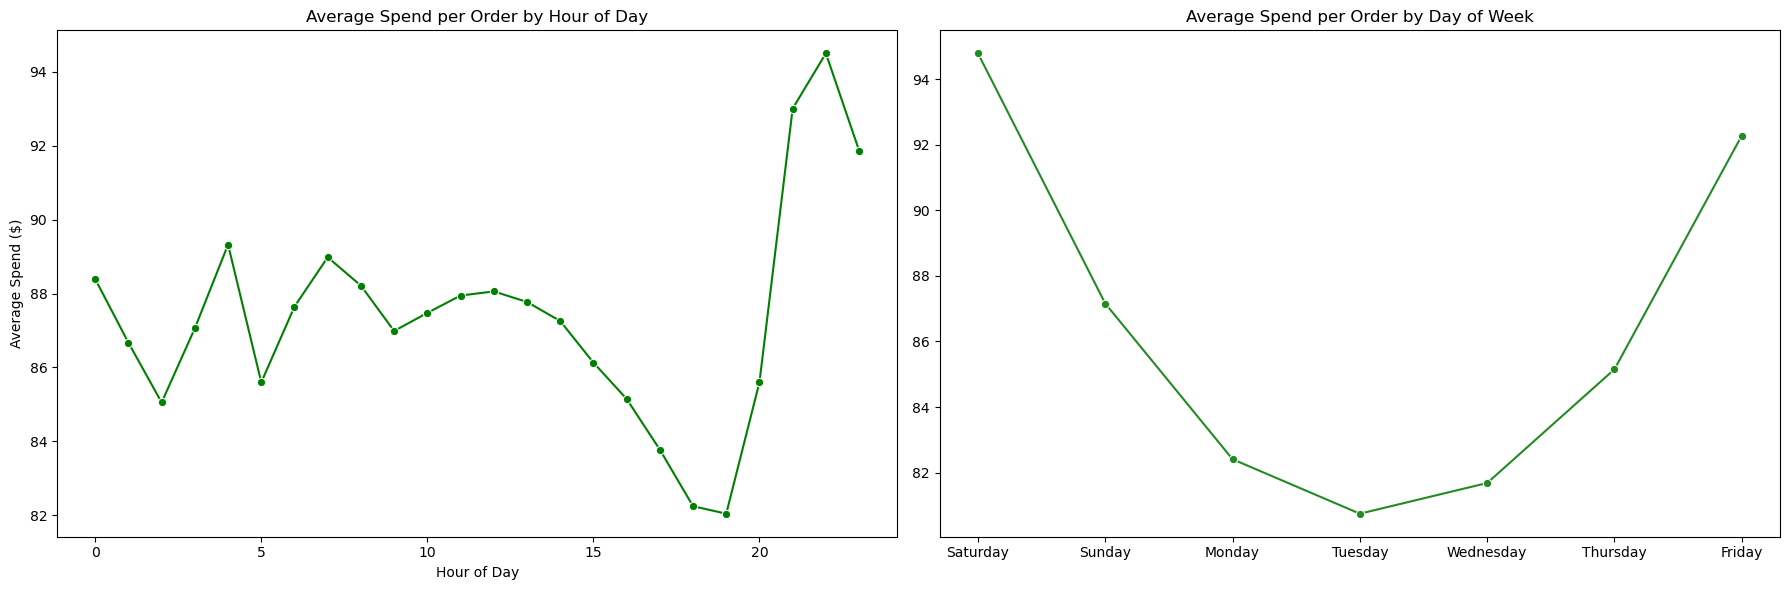

In [84]:
# Plotting side-by-side.

# Fig size
plt.figure(figsize=(18, 6))

# Plot 1: Hours
plt.subplot(1, 2, 1) 
avg_spend_order_hour = sns.lineplot(data=line_spend_hour, x='order_hour_of_day', y='avg_order_value', color='g', marker='o')
plt.title('Average Spend per Order by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Spend ($)')

# Plot 2: Days
plt.subplot(1, 2, 2)
avg_spend_order_day = sns.lineplot(data=line_spend_dow, x='order_dow', y='avg_order_value', color='forestgreen', marker='o')
plt.title('Average Spend per Order by Day of Week')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()

# Exporting figure
plt.savefig(
    os.path.join(
        path,
        '04 Insights & Visualizations',
        'line_chart_avg_spend_by_hour_&_dow.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### <u> **Higher-Value Orders Occur Outside Peak Shopping Hours**
- **Average order value remains relatively stable throughout the day**, ranging from approximately **\\$82 to \\$94** per order.
- **After around 8 PM**, average order value increases between 9-11 PM (hitting a peak at **10 PM**), despite evening and overnight hours accounting for **less than 20% of total orders**.
    - A smaller secondary peak occurs around **4 AM**, when order volume is at its lowest and the average order value is approximately **\\$89**. 
- Comparing the two charts, **average order value varies more by day than by hour**, with **Saturday (\\$94.78)** and **Friday (\\$92.27)** generating the highest average order values, while **Tuesday (\\$80.75)** has the lowest.

>***Later sections investigate whether these spending patterns reflect distinct shopping missions by examining basket composition and product purchasing behavior during these increases in order value.***

---

#### Order Value by Time Block

In [86]:
avg_spend_by_block = (
    df_order_behavior
        .drop_duplicates('order_id')
        .groupby('time_block', observed=True)['total_order_spend']
        .mean()
        .sort_values()
)

In [87]:
avg_spend_by_block

time_block
Evening      78.168949
Afternoon    78.311628
Overnight    78.576403
Morning      79.008882
Name: total_order_spend, dtype: float64

### <u>**Basket Size Alone Does Not Explain Differences in Order Value**</u>
**Average order value remains nearly identical across all time blocks (approximately \\$78–\\$79 per order)**, indicating that broad time-of-day groupings do not capture the hourly spending patterns observed earlier.
  > *Combined with the finding that **basket size also remains consistent throughout the day**, this suggests that higher-value orders observed during evening and overnight hours are likely influenced by **differences in the mix of products being purchased, rather than simply the number of items purchased**.*

---

## <div style = 'background-color: #fcc88d'> <center> <font color='#003d29'>   **3. Product Behavior: What Are Customers Buying?** </font> 
Since **order volume and basket size alone** cannot fully explain the elevated spend observed during evening and overnight periods, this section investigates whether product mix contributes to these patterns. By analyzing **department preferences**, **product-level lift**, and **category demand** across different time windows, we can uncover exactly what customers are buying during evening and overnight hours and why their spending patterns differ.

### **Top Departments** 
This analysis uses **product-level counts** to calculate the number of items purchased, not the number of orders to determine which products are most frequently purchased.

In [93]:
# Top departments by number of purchases. 
top_depts = (df_order_behavior['department'].value_counts(dropna=False).sort_values(ascending=False))
top_depts

department
produce            9479291
dairy eggs         5393058
snacks             2887550
beverages          2688123
frozen             2234743
pantry             1875369
bakery             1172428
canned goods       1068058
deli               1051249
dry goods pasta     866627
household           738666
meat seafood        708927
breakfast           703033
personal care       447572
babies              423794
international       269253
alcohol             153696
pets                 97716
missing              69145
other                36291
bulk                 34573
Name: count, dtype: int64

In [94]:
# By percent
top_depts_pct = (df_order_behavior['department'].value_counts(dropna=False, normalize=True).mul(100).sort_values(ascending=False))
top_depts_pct

department
produce            29.257828
dairy eggs         16.645671
snacks              8.912422
beverages           8.296891
frozen              6.897533
pantry              5.788326
bakery              3.618699
canned goods        3.296561
deli                3.244680
dry goods pasta     2.674844
household           2.279892
meat seafood        2.188103
breakfast           2.169911
personal care       1.381431
babies              1.308040
international       0.831049
alcohol             0.474383
pets                0.301600
missing             0.213416
other               0.112012
bulk                0.106710
Name: proportion, dtype: float64

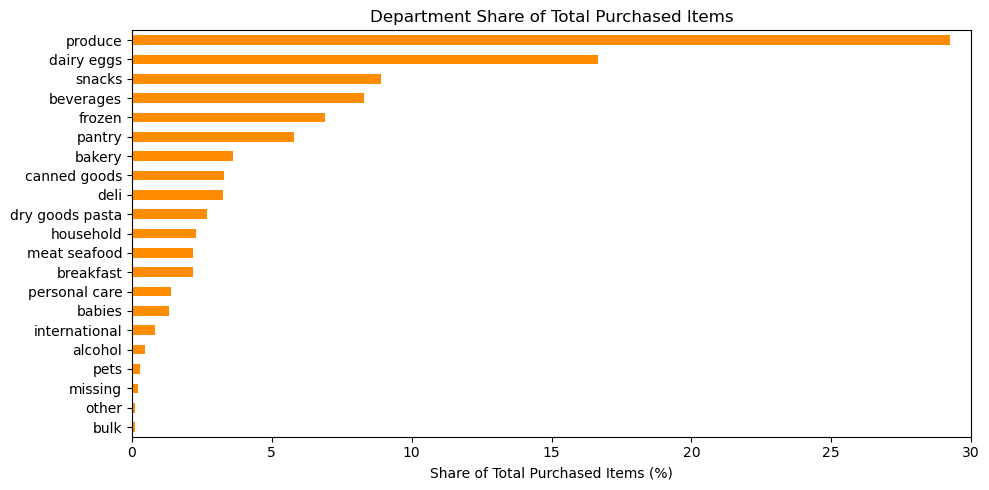

In [95]:
# Share of purchases by dept
plt.figure(figsize=(10, 5))

bar_top_dept_pct = top_depts_pct.plot(kind = 'barh', color = 'darkorange')

plt.title('Department Share of Total Purchased Items')
plt.xlabel('Share of Total Purchased Items (%)')
plt.ylabel('')
plt.xlim(0, 30)
plt.gca().invert_yaxis()  # Largest department at the top

plt.tight_layout()
plt.show()

### <u>**Top 5 Departments Account for 70% of All Purchases**
- **Produce** is the platform’s **most frequently purchased department**, accounting for **29.3%** of all purchased items.
- **Dairy & Eggs (16.6%)**, **Snacks (8.9%)**, **Beverages (8.3%)**, and **Frozen (6.9%)** round out the top five, which together form the **core of customer demand**.
- Together, these five departments make up nearly **70% of all purchases**, showing that **purchases are concentrated in a small set of product categories**.

<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;">
         Note: The "missing" department is an original category included in the Instacart dataset and does not represent records lost during data cleaning or merging.
    </p>

---

#### **Average Product Price by Department**
**To test whether differences in department popularity are driven by price rather than volume**, this section examines the average item price within each department. This will **help determine which categories are inherently low-cost and which consistently command higher prices**.

In [96]:
# On average how expensive are items in each dept.?
dept_avg_price = df_order_behavior.groupby('department', observed=True)['price'].mean().sort_values(ascending=False)

print("--- Department & Average Product Price ---")
print(dept_avg_price)

--- Department & Average Product Price ---
department
meat seafood       16.294443
missing             8.660716
bulk                8.348960
dairy eggs          8.335622
alcohol             8.143701
breakfast           8.028963
pantry              8.009443
personal care       7.996769
produce             7.981708
pets                7.889070
bakery              7.853809
deli                7.778701
frozen              7.736553
international       7.682264
beverages           7.680502
babies              7.638260
canned goods        7.539976
household           7.384058
dry goods pasta     7.350283
other               6.990934
snacks              4.275437
Name: price, dtype: float64


### <u>**Average Product Prices Vary Significantly Across Departments** </u>
- **Meat & Seafood** has the highest average price per item (**~ \\$16.29**), more than double the price in most of the other departments.
- Around 90% of the departments have similar average prices ranging from **\\$7 to \\$8**.
- **Snacks** stands out as the lowest-priced department with each item costing approximately **\\$4.28**.
> *These pricing differences help explain how **higher-priced departments can have a greater impact on order value even with fewer items purchased**.*

#### When a department appears in an order, what percent of the total order spend does it represent?

In [97]:
# 1. Calculating the department spend and pulling the order's total spend - making a table
order_dept_shares = (
    df_order_behavior
    .groupby(['order_id', 'department'], observed=True)
    .agg(
        dept_spend=('price', 'sum'),
        total_order_spend=('total_order_spend', 'first')
    )
    .reset_index()
)


In [98]:
# 2. Calculating what % of the cart that department took up for that order. 
order_dept_shares['cart_share_pct'] = (order_dept_shares['dept_spend'] / order_dept_shares['total_order_spend']) * 100

In [99]:
# 3. Finding the average cart share percentage for each department.
avg_cart_share = (
    order_dept_shares
    .groupby('department', observed=True)['cart_share_pct']
    .mean()
    .sort_values(ascending=False)
)

print("--- Average % Share of the Cart When Purchased ---")
print(avg_cart_share.round(2))

--- Average % Share of the Cart When Purchased ---
department
produce            38.68
alcohol            33.22
dairy eggs         25.90
beverages          22.52
meat seafood       21.07
babies             18.08
pets               17.95
frozen             17.95
household          17.88
personal care      16.85
pantry             16.44
snacks             13.83
breakfast          13.17
bakery             12.94
deli               12.81
canned goods       12.70
bulk               12.06
missing            11.77
other              11.67
dry goods pasta    11.35
international      10.43
Name: cart_share_pct, dtype: float64


### <u>  **Produce Accounts for Over One-Third of Cart Value When Purchased** </u>
- When **Produce** is purchased, it represents approximately **38.7% of the total order value**, making it the **largest average cart share of any department.**.
- **Alcohol (33.2%)**, **Dairy & Eggs (25.9%)**, **Beverages (22.5%)**, and **Meat & Seafood (21.1%)** also account for a substantial share of cart value when included in an order. 
- In contrast, **Snacks** account for an average of **13.8% of cart value** when purchased, suggesting that they tend to represent a **smaller portion of the overall basket** rather than serving as primary basket drivers.

> *These differences help **distinguish departments** that anchor customer baskets from those that primarily complement existing purchases, providing **insight into merchandising opportunities** and **more targeted product recommendations.***

---

#### Departments by Time Block 
This calculates for each time block, what percentage of all purchased items came from each department.

In [100]:
# Investigating what departments are being bought at night (driving the spend spikes).

# 1. Count items by time_block x department
dept_item_counts = (
    df_order_behavior
        .groupby(['time_block', 'department'], observed=True)
        .size() # Count of items per dept. 
        .reset_index(name='item_count')
)

In [101]:
# 2. Within each time_block, convert counts to percentages.
dept_item_counts['pct_of_items'] = (
    dept_item_counts
        .groupby('time_block', observed=True)['item_count']
        .transform(lambda x: x / x.sum() * 100)
)

In [102]:
# Percent of items from each department per block - table check
dept_item_counts.head()

,time_block,department,item_count,pct_of_items
0,Afternoon,alcohol,84005,0.550822
1,Afternoon,babies,184755,1.211442
2,Afternoon,bakery,558182,3.660008
3,Afternoon,beverages,1258701,8.253323
4,Afternoon,breakfast,318301,2.087105


In [103]:
# 3. Pivot for table
dept_count_pivot = (
    dept_item_counts
        .pivot(index='department', columns='time_block', values='pct_of_items')
        .round(2)
)

# Changing order from alphabetical to actual order. 
reorder = ['Morning', 'Afternoon', 'Evening', 'Overnight']
dept_count_pivot = dept_count_pivot[reorder]

In [104]:
dept_count_pivot

time_block,Morning,Afternoon,Evening,Overnight
department,,,,
alcohol,0.42,0.55,0.39,0.29
babies,1.39,1.21,1.43,1.05
bakery,3.63,3.66,3.52,3.40
beverages,8.57,8.25,7.87,8.50
breakfast,2.29,2.09,2.17,2.04
bulk,0.11,0.10,0.11,0.10
canned goods,3.20,3.39,3.22,3.34
dairy eggs,17.19,16.33,16.55,15.69
deli,3.17,3.31,3.24,3.17


### <u>**Department Preferences Remain Stable Across Time Blocks** </u>
Even during off-peak spend spikes, overall department composition remains stable, with core categories such as **Produce** and **Dairy & Eggs** maintaining consistent shares of purchased items across all time periods

> *This suggests that **differences in average order value** observed during **evening and overnight hours** are **not driven by broad department preferences**, but rather by **differences in specific products** customers buy within those departments.*

> ***Later analyses examines product-level purchasing behavior to identify whether differences in product preference help explain these spending patterns.***

---

### Product Price Distribution
Understanding how product prices are distributed provides insight into the types of products that make up Instacart’s catalog, from lower-cost to higher-priced items. Examining the **price distribution establishes a baseline** for **identifying price tiers** and assessing how these tiers vary across different departments, products, and customer purchasing behaviors.

In [105]:
# Number of unique products. 
df_order_behavior['product_id'].nunique()

49657

In [106]:
# Price stats. 
df_order_behavior['price'].describe()

count    3.239916e+07
mean     7.791077e+00
std      4.241796e+00
min      1.000000e+00
25%      4.200000e+00
50%      7.400000e+00
75%      1.130000e+01
max      2.500000e+01
Name: price, dtype: float64

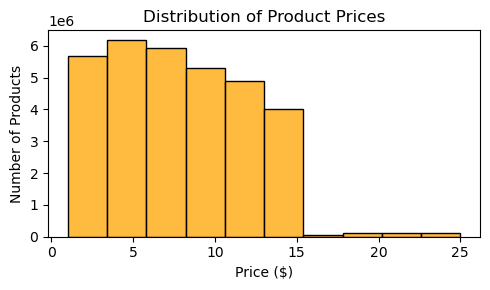

In [107]:
# Histogram - price distribution
plt.figure(figsize=(5,3))
price_hist = sns.histplot(df_order_behavior['price'], bins=10, edgecolor='black', color='orange')
plt.title('Distribution of Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()      

In [108]:
# Representing low-cost items (25th percentile).
df_order_behavior.loc[df_order_behavior['price'] <= 5, 'product_price_tier'] = 'low-cost'

In [109]:
# Staple items - mid-range in price - majority of items (based on histogram)
df_order_behavior.loc[(df_order_behavior['price'] > 5) & (df_order_behavior['price'] <= 15) , 'product_price_tier'] = 'mid-range'

In [110]:
# Premium products (> $15 based on histogram).
df_order_behavior.loc[df_order_behavior['price'] > 15, 'product_price_tier'] = 'high-cost'

In [111]:
# Checking counts of each category (product-level) - checking for nulls
df_order_behavior['product_price_tier'].value_counts(dropna=False)

product_price_tier
mid-range    21860852
low-cost     10125759
high-cost      412551
Name: count, dtype: int64

In [112]:
# Converting counts to percentages. 
df_order_behavior['product_price_tier'].value_counts(dropna=False, normalize=True)*100

product_price_tier
mid-range    67.473511
low-cost     31.253151
high-cost     1.273338
Name: proportion, dtype: float64

### <u>**Approximately 67.5% of Purchases Fall Between \\$5 and \\$15**<u>
- Approximately **67.5%** of all purchased items fall within the **mid-range price tier (\\$5–\\$15)**, while **31.3%** are **low-cost items (\\$5 or less)**.
- **High-cost items (more than \\$15)** represent only **1.3%** of all items purchased.
> *Given the relatively small share of high-cost items and the consistency of basket sizes, these findings suggest that **differences in order value are more likely related to the mix of products** customers purchase rather than expensive individual items alone.*

### Price Flags by Time Block 
This analysis examines whether differences in order value across time blocks are associated with **changes in the mix of low-, mid-, and high-priced products purchased**.

In [113]:
# Counting items by price tier and time block.
price_tiers_by_block = (
    df_order_behavior
        .groupby(['time_block', 'product_price_tier'], observed=True)
        .size()
        .reset_index(name='item_count')
)

In [114]:
# Converting to percentages.
price_tiers_by_block['pct_of_items'] = (
    price_tiers_by_block
        .groupby('time_block', observed=True)['item_count']
        .apply(lambda x: x / x.sum() * 100)
        .values
)


In [115]:
# Pivoting for better readability.
price_tier_pivot = (
    price_tiers_by_block
        .pivot(index='product_price_tier', columns='time_block', values='pct_of_items')
        .round(2)
)
price_tier_pivot

time_block,Afternoon,Evening,Morning,Overnight
product_price_tier,,,,
high-cost,1.30,1.26,1.24,1.25
low-cost,31.18,31.09,31.45,31.10
mid-range,67.51,67.65,67.31,67.66


### <u>**Product Price Tiers Remain Consistent Across Time Blocks** </u>
- The distribution of **low-cost**, **mid-range**, and **high-cost products** remain **nearly identical across all time blocks**.

> *With high-cost items and department composition holding stable across all time windows, **price tiers alone do not explain off-peak spend spikes**. Instead, this **strongly suggests that product mix** may be the **differentiating factor** behind temporal spending shifts.*

---

## <center> <font color='darkorange'> <u>  **3.2 Product-Level Behavior (Product Lift Analysis)**</u>
Since basket size, department mix, and price‑tier composition remain stable throughout the day, this section explores **product-level purchasing patterns** to better understand the **higher order values** observed during **evening and overnight** windows. 


#### Product Lift by Time Block

In [120]:
# 1. Getting overall product counts (total purchases).
overall_prod_counts = df_order_behavior.groupby('product_id').size()

## Total purchases.
total_product_purchases = overall_prod_counts.sum()

In [121]:
overall_prod_counts.sum()

np.int64(32399162)

In [122]:
total_product_purchases

np.int64(32399162)

In [123]:
# 2. Counting products by time block. 
prod_by_block = df_order_behavior.groupby(['product_id', 'product_name', 'time_block'], observed=True).size().reset_index(name='count_in_block')

In [124]:
# 3. Mapping the counts to the product id. 
prod_by_block['overall_count'] = prod_by_block['product_id'].map(overall_prod_counts)

In [125]:
# 4. Mapping product prices - first creating a series of unique products with their price 
price_map = (
    df_order_behavior[['product_id', 'price']]
        .drop_duplicates('product_id')
        .set_index('product_id')['price']
)

In [126]:
# 5. Mapping prices to product ids. 
prod_by_block['price'] = prod_by_block['product_id'].map(price_map)

In [127]:
prod_by_block.head()

,product_id,product_name,time_block,count_in_block,overall_count,price
0,1,Chocolate Sandwich Cookies,Afternoon,898,1852,5.8
1,1,Chocolate Sandwich Cookies,Evening,272,1852,5.8
2,1,Chocolate Sandwich Cookies,Morning,634,1852,5.8
3,1,Chocolate Sandwich Cookies,Overnight,48,1852,5.8
4,2,All-Seasons Salt,Afternoon,46,90,9.3


In [128]:
# 6. Department map. 
dept_map = (
    df_clean[['product_id', 'department']]
        .drop_duplicates('product_id')
        .set_index('product_id')['department']
)

In [129]:
# 7. Mapping dept. names to see which specific dept. a product is from. 
prod_by_block['department'] = prod_by_block['product_id'].map(dept_map)

In [130]:
# 8. Calculating product lift.

## Count in block rate.
prod_by_block['pct_in_block'] = (
    prod_by_block['count_in_block'] /
    prod_by_block.groupby('time_block', observed=True)['count_in_block'].transform('sum')
)

## Overall rate.
prod_by_block['pct_overall'] = (
    prod_by_block['overall_count'] /
    total_product_purchases
)

## Lift - product representation
prod_by_block['lift'] = (
    prod_by_block['pct_in_block'] /
    prod_by_block['pct_overall']
)


In [131]:
# Check shape before filtering. 
prod_by_block.shape

(175657, 10)

#### Filtering

In [132]:
# 9. Filtering out low count products - otherwise the lift will be huge and irrelevant (don't want to see products only bought 1x and have a large lift)
prod_by_block_filtered = prod_by_block[
    (prod_by_block['overall_count'] > 1000) &
    (prod_by_block['count_in_block'] > 100)
]

In [133]:
# Checking for nulls. 
prod_by_block_filtered.isnull().sum()

product_id        0
product_name      0
time_block        0
count_in_block    0
overall_count     0
price             0
department        0
pct_in_block      0
pct_overall       0
lift              0
dtype: int64

#### Evening (6-11:59PM) Lift 

In [134]:
# Checking which specific products are being bought in the evening block (during the 10 PM primary spike).
evening_spike = (
    prod_by_block_filtered[prod_by_block_filtered['time_block'] == 'Evening']
        .sort_values('lift', ascending=False)
        .head(20)
)

#### Overnight (12-5AM) Lift

In [135]:
# Checking which specific products are being bought in the late night block (during the 4 AM secondary spike).
overnight_spike = (
    prod_by_block_filtered[prod_by_block_filtered['time_block'] == 'Overnight']
        .sort_values('lift', ascending=False)
        .head(20)
)

<div style="background-color: white; padding: 15px; margin-bottom: 15px; border-left: 5px solid #ffbb6e; border-radius: 4px; color: #333;">
   <center> <h3 style="color: #442202; margin-top: 0; font-size: 24px; font-weight: bold;"> Evening Product Behavior </h3>
</div>


This section examining which products are overrepresented during **evening hours (6:00 PM–11:59 PM)**. 

- <u>**Lift:** </u>
    - **Product Overrepresentation:** Measures how much more (or less) frequently a product is purchased within a specific time block compared to its overall purchase frequency. **Values greater than 1** indicate the **product is overrepresented** during that time period.
       - **Lift > 1:** The product is overrepresented in this time block compared to its overall purchasing frequency.
       - **Lift = 1:** The product appears as often as expected.
       -  **Lift < 1:** The product is underrepresented in this time block.
- <u>**Purchase Volume:** </u>
    - **Popularity:** Identifies which products with the highest purchase counts.
- <u>**Estimated Spend Impact:**</u>
    - **Spend Contribution:** Identifies which products are contributing to the spend differences during the 10PM and 4AM spending spikes.
 
<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;">
         Note: Products with fewer than 1,000 purchases overall were excluded to reduce noise from low-frequency items.
    </p>

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
         <center>Top 10 Evening Products (by lift)     </h3> 
    
This table highlights the top 10 products with the highest lift during evening hours, identifying **items that are purchased more frequently than expected** during this time period and **helping explain the 10 PM spending spike**.
    </h3> 
</div>

In [136]:
# Highest lift - finds overindexed products during evening hours
evening_spike.sort_values('lift', ascending=False).head(10).style.background_gradient(subset=['lift'], cmap='YlGn')

,product_id,product_name,time_block,count_in_block,overall_count,price,department,pct_in_block,pct_overall,lift
164267,46475,Chocolate Chip Cookie Dough Frozen Greek Yogurt Bars,Evening,313,1028,2.300000,frozen,0.000055,0.000032,1.729991
59539,16874,Chocolate Fudge Brownie Ice Cream,Evening,639,2346,14.500000,frozen,0.000112,0.000072,1.547624
136683,38679,Peanut Butter Fudge Core Ice Cream,Evening,294,1112,10.100000,frozen,0.000052,0.000034,1.502226
48968,13889,Cashew Milk Salted Caramel Cluster Non-Dairy Frozen Dessert,Evening,337,1281,1.900000,frozen,0.000059,0.000040,1.494767
160959,45541,The Tonight Dough™ Ice Cream,Evening,775,2973,8.600000,frozen,0.000136,0.000092,1.481151
74851,21198,Coconut Milk Non Dairy Frozen Dessert No Sugar Added Mint Chip,Evening,317,1221,8.400000,frozen,0.000056,0.000038,1.475150
44546,12658,Cashew Milk Snickerdoodle Non-Dairy Frozen Dessert,Evening,271,1044,5.800000,frozen,0.000048,0.000032,1.474896
108367,30668,Half Baked Frozen Yogurt,Evening,735,2844,13.200000,frozen,0.000129,0.000088,1.468420
31956,9065,Mint Chocolate Cookie Ice Cream,Evening,499,1944,6.600000,frozen,0.000088,0.000060,1.458468
40481,11494,Cookie Dough Ice Cream Chocolate Chip,Evening,336,1311,8.500000,missing,0.000059,0.000040,1.456227


### <u>**Frozen Desserts Are Purchased More Frequently During Evening Hours**</u>
- During evening hours, the products with the highest lift are primarily from the Frozen department, mainly consisting of **frozen desserts with higher price points** within their category (such as **frozen yogurt**, **non-dairy alternatives**, **premium ice cream brands**, etc.).
- These products have **lift values** ranging from **1.4x to 1.7x**, meaning they are purchased **40–70% more frequently than expected** during evening hours compared with their overall purchase frequency.
> *This pattern suggests that **evening shoppers exhibit distinct product preferences**, with greater interest in **frozen treats** than everyday grocery staples. Identifying these **time-specific preferences** could help **improve product relevance by informing more targeted recommendations based on when customers shop.***

---

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
       <center> Top 10 Evening Products (by volume)     </h3> 
    
This table highlights the top 10 **most frequently purchased products** during evening hours, identifying the items that contribute most to overall purchasing activity.
    </h3> 
</div>

In [137]:
# Highest volume
evening_spike.sort_values('count_in_block', ascending=False).head(10).style.background_gradient(subset=['count_in_block'], cmap='YlGn')

,product_id,product_name,time_block,count_in_block,overall_count,price,department,pct_in_block,pct_overall,lift
160959,45541,The Tonight Dough™ Ice Cream,Evening,775,2973,8.600000,frozen,0.000136,0.000092,1.481151
108367,30668,Half Baked Frozen Yogurt,Evening,735,2844,13.200000,frozen,0.000129,0.000088,1.468420
59539,16874,Chocolate Fudge Brownie Ice Cream,Evening,639,2346,14.500000,frozen,0.000112,0.000072,1.547624
31956,9065,Mint Chocolate Cookie Ice Cream,Evening,499,1944,6.600000,frozen,0.000088,0.000060,1.458468
55312,15683,Caribbean Coconut Gelato,Evening,484,1967,7.400000,frozen,0.000085,0.000061,1.398085
51009,14464,Dulce de Leche Caramel Ice Cream,Evening,432,1708,5.600000,frozen,0.000076,0.000053,1.437105
158180,44753,New York Super Fudge Chunk® Ice Cream,Evening,408,1644,10.700000,frozen,0.000072,0.000051,1.410103
132559,37511,Organic Cookies & Cream Ice Cream,Evening,403,1656,9.000000,frozen,0.000071,0.000051,1.382730
159092,45009,Chocolate Chocolate Chip Ice Cream,Evening,351,1405,13.000000,frozen,0.000062,0.000043,1.419461
48968,13889,Cashew Milk Salted Caramel Cluster Non-Dairy Frozen Dessert,Evening,337,1281,1.900000,frozen,0.000059,0.000040,1.494767


### <u>**High-Lift Evening Products Are Also Frequently Purchased** </u>
Frozen desserts exhibit **both high lift and high purchase volume**, suggesting that the evening purchasing pattern reflects **meaningful demand for these products rather than a small number of infrequent purchases.**

---

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
      <center> Top 20 Evening Products by Estimated Incremental Spend    </h3> 
    
- To estimate which products may contribute most to elevated evening spending, an **Estimated Spend Impact** metric was calculated as:
                                            <center>    **(Lift - 1) x Purchase Count in Block x Price** 
- By **combining product overrepresentation (lift), purchase volume, and price**, this metric highlights the products that are associated with **higher spending during the 10 PM spending peak**.
  
<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;"> Note: Estimated Spend Impact is a custom metric designed to estimate each product's contribution to elevated spending.
</p>

In [138]:
# Highest revenue impact - EVENING 
evening_spike['spend_impact'] = (
    (evening_spike['lift'] - 1)
    * evening_spike['count_in_block']
    * evening_spike['price']
)

In [139]:
# Sorting values - Which products can explain the higher order values vs baseline during evening?
evening_spike.sort_values('spend_impact', ascending=False).head(20).style.background_gradient(subset=['spend_impact'], cmap='YlGn')

,product_id,product_name,time_block,count_in_block,overall_count,price,department,pct_in_block,pct_overall,lift,spend_impact
59539,16874,Chocolate Fudge Brownie Ice Cream,Evening,639,2346,14.500000,frozen,0.000112,0.000072,1.547624,5074.010858
108367,30668,Half Baked Frozen Yogurt,Evening,735,2844,13.200000,frozen,0.000129,0.000088,1.468420,4544.613543
160959,45541,The Tonight Dough™ Ice Cream,Evening,775,2973,8.600000,frozen,0.000136,0.000092,1.481151,3206.873315
159092,45009,Chocolate Chocolate Chip Ice Cream,Evening,351,1405,13.000000,frozen,0.000062,0.000043,1.419461,1913.999856
158180,44753,New York Super Fudge Chunk® Ice Cream,Evening,408,1644,10.700000,frozen,0.000072,0.000051,1.410103,1790.347637
31956,9065,Mint Chocolate Cookie Ice Cream,Evening,499,1944,6.600000,frozen,0.000088,0.000060,1.458468,1509.918585
136683,38679,Peanut Butter Fudge Core Ice Cream,Evening,294,1112,10.100000,frozen,0.000052,0.000034,1.502226,1491.308808
55312,15683,Caribbean Coconut Gelato,Evening,484,1967,7.400000,frozen,0.000085,0.000061,1.398085,1425.781834
132559,37511,Organic Cookies & Cream Ice Cream,Evening,403,1656,9.000000,frozen,0.000071,0.000051,1.382730,1388.161186
40481,11494,Cookie Dough Ice Cream Chocolate Chip,Evening,336,1311,8.500000,missing,0.000059,0.000040,1.456227,1302.985586


### <u> **Frozen Desserts Shape Evening Spending Patterns**</u>
- Frozen desserts demonstrate both **strong evening overrepresentation and substantial estimated spend**, indicating that they are not only purchased more frequently during evening hours but may also contribute substantially to higher evening order values.
- Products such as **Chocolate Fudge Brownie Ice Cream**, **Half Baked Frozen Yogurt**, and **The Tonight Dough™ Ice Cream** show lift values between **1.47x and 1.55x**, meaning they are purchased approximately **47–55% more frequently than expected** during evening hours.
- Together, the **top three products** alone account for approximately **$12,825.50 in estimated incremental spend**, suggesting that the **10 PM spending spike is associated with shift in product mix towards frozen desserts**.

> *These findings further support product mix as a key differentiating factor in evening spending patterns and highlight an **opportunity to improve product relevance** by **incorporating these time-specific purchasing preferences into recommendations.***

---

<div style="background-color: white; padding: 15px; margin-bottom: 15px; border-left: 5px solid #ffbb6e; border-radius: 4px; color: #333;">
  <center>  <h3 style="color: midnightblue; margin-top: 0; font-size: 24px; font-weight: bold;"> Overnight Product Behavior </h3>
</div>

This section examines **which products are overrepresented overnight (12:00 AM–5:00 AM)**, identifying **which products contribute to the 4 AM spending peak**.
      
<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;">
         Note: Products with fewer than 1,000 purchases overall were excluded to reduce noise from low-frequency items.
    </p>

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: midnightblue ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
      <center> Top 10 Overnight Products (by lift)     </h3> 
</div>

In [140]:
# Highest lift - finds unusual products 
overnight_spike.sort_values('lift', ascending=False).head(10).style.background_gradient(subset=['lift'], cmap='YlGn')

,product_id,product_name,time_block,count_in_block,overall_count,price,department,pct_in_block,pct_overall,lift
79902,22610,Reduced Fat 2% Lactose-Free Milk,Overnight,107,3050,9.400000,dairy eggs,0.000179,0.000094,1.906384
40039,11365,Leaf Spinach,Overnight,146,4337,9.800000,produce,0.000245,0.000134,1.829321
3241,920,Coconut Yogurt,Overnight,105,3157,1.100000,dairy eggs,0.000176,0.000097,1.807346
117167,33147,Organic Crimini Mushrooms,Overnight,129,3879,9.800000,produce,0.000216,0.000120,1.807159
149419,42282,Bag of Jumbo Yellow Onions,Overnight,102,3175,1.600000,produce,0.000171,0.000098,1.745754
21787,6182,Natural Artesian Bottled Water,Overnight,155,4855,5.400000,beverages,0.000260,0.000150,1.734878
144371,40852,Lactose Free Fat Free Milk,Overnight,143,4650,4.000000,dairy eggs,0.000240,0.000144,1.671128
88095,24933,Turmeric Root,Overnight,106,3453,11.800000,produce,0.000178,0.000107,1.668153
49251,13966,Chicken Pot Pie,Overnight,168,5484,10.700000,frozen,0.000282,0.000169,1.664709
97256,27531,Dairy Free Unsweetened Vanilla Coconut Milk,Overnight,111,3663,4.500000,dairy eggs,0.000186,0.000113,1.646693


### <u>**Routine Grocery Items Are Overrepresented During Overnight Hours**</u>
- Unlike the evening period where frozen desserts are strongly overrepresented, **overnight purchases** are more strongly associated with **Produce**  **Dairy & Eggs**, including products such as **spinach, lactose-free milk, mushrooms, and yogurt**.
- This shift further demonstrates that **time of day captures meaningful differences in product preferences**, with overnight shoppers exhibiting a distinct product mix centered more on routine grocery items.
  
> *These temporal distinctions reinforce the value of **incorporating shopping context into product recommendations**, as the products most relevant to customers may vary meaningfully depending on when they shop.*

---

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: midnightblue ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
       <center> Top 10 Overnight Products (by volume)    </h3> 
</div>

In [141]:
# Highest volume - popular products 
overnight_spike.sort_values('count_in_block', ascending=False).head(10).style.background_gradient(subset=['count_in_block'], cmap='YlGn')

,product_id,product_name,time_block,count_in_block,overall_count,price,department,pct_in_block,pct_overall,lift
31235,8859,Natural Spring Water,Overnight,546,19518,4.800000,beverages,0.000916,0.000602,1.520141
10038,2846,Organic Green Onions,Overnight,233,8138,3.800000,produce,0.000391,0.000251,1.555839
16611,4724,Broccoli Florettes,Overnight,218,7311,7.800000,produce,0.000366,0.000226,1.620340
63192,17902,Liquid Egg Whites,Overnight,202,6763,11.800000,dairy eggs,0.000339,0.000209,1.623075
49251,13966,Chicken Pot Pie,Overnight,168,5484,10.700000,frozen,0.000282,0.000169,1.664709
21787,6182,Natural Artesian Bottled Water,Overnight,155,4855,5.400000,beverages,0.000260,0.000150,1.734878
40039,11365,Leaf Spinach,Overnight,146,4337,9.800000,produce,0.000245,0.000134,1.829321
144371,40852,Lactose Free Fat Free Milk,Overnight,143,4650,4.000000,dairy eggs,0.000240,0.000144,1.671128
81912,23178,Pure Lemon Juice,Overnight,131,4372,11.000000,beverages,0.000220,0.000135,1.628237
117167,33147,Organic Crimini Mushrooms,Overnight,129,3879,9.800000,produce,0.000216,0.000120,1.807159


### <u>**Overnight Order Volume Focuses on Pantry Staples** </u>
- Unlike evening orders, overnight purchases over-index in the **Produce**, **Dairy & Eggs**, and **Beverage** categories.
- Products such as **Natural Spring Water, Liquid Egg Whites, and Organic Green Onions** suggest that overnight purchasing is more closely aligned with **routine grocery replenishment**, contrasting with the frozen dessert patterns observed during the evening.

---

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: midnightblue ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
          <center>  Top 20 Overnight Products by Estimated Incremental Spend    </h3> 
   </h3> 

Tthis table highlights the top 20 products with the **highest estimated spend** during overnight hours, identifying the **products that contribute most to the 4 AM spending spike**.
</div>

<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;"> Note: Estimated Spend Impact is a custom metric designed to estimate each product's contribution to elevated spending.
</p>

In [142]:
# Highest revenue impact 
overnight_spike['spend_impact'] = (
    (overnight_spike['lift'] - 1)
    * overnight_spike['count_in_block']
    * overnight_spike['price']
)

In [143]:
# Sorting values - Which products help explain the increase in order value during overnight spend vs baseline?
overnight_spike.sort_values('spend_impact', ascending=False).head(20).style.background_gradient(subset=['spend_impact'], cmap='YlGn')

,product_id,product_name,time_block,count_in_block,overall_count,price,department,pct_in_block,pct_overall,lift,spend_impact
63192,17902,Liquid Egg Whites,Overnight,202,6763,11.800000,dairy eggs,0.000339,0.000209,1.623075,1485.160700
31235,8859,Natural Spring Water,Overnight,546,19518,4.800000,beverages,0.000916,0.000602,1.520141,1363.185214
49251,13966,Chicken Pot Pie,Overnight,168,5484,10.700000,frozen,0.000282,0.000169,1.664709,1194.881015
40039,11365,Leaf Spinach,Overnight,146,4337,9.800000,produce,0.000245,0.000134,1.829321,1186.592622
16611,4724,Broccoli Florettes,Overnight,218,7311,7.800000,produce,0.000366,0.000226,1.620340,1054.826550
117167,33147,Organic Crimini Mushrooms,Overnight,129,3879,9.800000,produce,0.000216,0.000120,1.807159,1020.410800
79902,22610,Reduced Fat 2% Lactose-Free Milk,Overnight,107,3050,9.400000,dairy eggs,0.000179,0.000094,1.906384,911.641304
81912,23178,Pure Lemon Juice,Overnight,131,4372,11.000000,beverages,0.000220,0.000135,1.628237,905.289688
88095,24933,Turmeric Root,Overnight,106,3453,11.800000,produce,0.000178,0.000107,1.668153,835.725363
120213,34005,Black Seedless Grapes,Overnight,110,3938,12.600000,produce,0.000184,0.000122,1.517901,717.810956


### **<u>Overnight Incremental Spend Is Driven by Product Volume, Not Price** </u>
- The top 20 products with the **highest estimated incremental spend** closely align with the highest-volume overnight purchases, with **all top 20 products priced below \\$15**. This suggests that elevated overnight spending is driven primarily by **frequent purchases of specific products rather than higher-priced individual items**.
- Products such as **Leaf Spinach, Organic Crimini Mushrooms, Liquid Egg Whites, and water products** consistently appear across the **lift, volume, and estimated spend analyses**, highlighting a concentrated demand for **pantry items and meal ingredients**.

> *These findings suggest that **overnight spend variations** are primarily driven by **product volume and shopping frequency** rather a shift toward more buying more expensive items. Recommendation algorithms targeting overnight shoppers could therefore prioritize high-reorder staples over premium upsells.*

---

### <center> **Insight Summary: Time-of-Day Differences in Product Mix** </br>
- **Evening orders** show stronger demand for **frozen desserts**, particularly higher-priced products within the Frozen department, contributing to greater estimated incremental spend.
- **Overnight orders** are more strongly associated with **everyday grocery items** across **Produce**, **Dairy & Eggs**, and **Beverages**, **reflecting a different product mix**.
- With **price-tier distributions remaining stable across time blocks**, the evidence suggests that differences in spending are primarily associated with **which products customers purchase rather than broad differences in price preferences**.
> ***Overall, time of day provides a meaningful behavioral signal that can be used to inform more contextually relevant product recommendations.***

---

<div style="background-color: white; padding: 15px; margin-bottom: 15px; border-left: 5px solid #ffbb6e; border-radius: 4px; color: #333;">
  <center>  <h3 style="color:; margin-top: 0; font-size: 24px; font-weight: bold;"> <u>Weekend vs. Weekday Purchasing Patterns </h3>
</div>

Understanding how shopping behavior changes throughout the week helps identify whether differences in spending are driven by changes in purchasing patterns or product selection. This section first compares **order behavior across weekdays, Friday, and weekends** before examining how product mix differs across these periods.


#### Weekend vs. Weekday Flags

In [144]:
# 1. Creating a 3-tier classification - Separating Friday - Not part of the weekend or weekday

## Creating a dictionary to define this (less memory and faster).
day_mapping = {
    'Monday': 'weekday', 'Tuesday': 'weekday', 'Wednesday': 'weekday', 'Thursday': 'weekday',
    'Friday': 'transition',
    'Saturday': 'weekend', 'Sunday': 'weekend'
}

# Mapping values (using the order data).
df_order_behavior['week_split'] = df_order_behavior['order_dow'].map(day_mapping)

In [145]:
# Converting column to be a category to save memory. 
df_order_behavior['week_split'] = df_order_behavior['week_split'].astype('category')

In [146]:
# Verifying every record received a week_split label. 
week_labels = df_order_behavior['week_split'].value_counts(dropna=False)
week_labels

week_split
weekday       16040972
weekend       11862390
transition     4495800
Name: count, dtype: int64

#### Total Unique Orders by Week Split

In [147]:
# How many orders are placed by week split? (Order-level, droppping dups)
orders_week_split = (
    df_order_behavior[['order_id', 'week_split']]
    .drop_duplicates(subset='order_id')
    .groupby('week_split', observed=True)
    .size()
)

orders_week_split

week_split
transition     418827
weekday       1681422
weekend       1114419
dtype: int64

#### Average Spend By Week Split
This answers across all orders by week split , what is the average order spend?

In [148]:
# Order-level average spend by week split - dropping dups 
week_split_spend_corrected = (
    df_order_behavior.drop_duplicates(subset='order_id')
    .groupby('week_split', observed=True)['total_order_spend']
    .mean()
    .sort_values()
)

In [149]:
week_split_spend_corrected

week_split
weekday       74.009711
weekend       83.143740
transition    84.344750
Name: total_order_spend, dtype: float64

#### Basket Size By Week Split

In [150]:
# Checking basket size by day - average number of items 
df_order_behavior.groupby('week_split', observed=True)['order_total_items'].mean().sort_values()

week_split
weekday       15.168370
weekend       16.164562
transition    16.278571
Name: order_total_items, dtype: float64

In [151]:
# By basket size - crosstab with percentages
baskets_by_split = pd.crosstab(df_order_behavior['basket_size'], df_order_behavior['week_split'], normalize='columns') * 100
baskets_by_split

week_split,transition,weekday,weekend
basket_size,,,
bulk basket,8.070733,7.062789,7.778685
large basket,42.086125,36.911548,41.853615
medium basket,41.557721,44.750162,41.900544
small basket,8.285422,11.275501,8.467155


### <u> **Friday Shopping Signals the Start of Weekend Behavior**
- Although **Friday** accounts for the **fewest orders (418,827)**, it has the **highest average order value (\\$84.34)**, compared with **\\$74.01 on weekdays** and **\\$83.14 on weekends**.
- This is driven in part by **larger baskets**, with customers purchasing approximately **one additional item per order** compared with weekdays, representing a **7.3% increase in basket size**.
- With **Friday shopping patterns closely matching weekend levels**, it appears to **mark the transition into weekend purchasing behavior** rather than simply the end of the weekday shopping period.

> ***These patterns suggest that weekend-oriented shopping behavior actually begins before the weekend (Saturday-Sunday), prompting a closer look at the products driving Friday purchases in the next section.***

---

<div style="background-color: white; padding: 15px; margin-bottom: 15px; border-left: 5px solid #ffbb6e; border-radius: 4px; color: #333;">
    <h3 style="color: #442202; margin-top: 0; font-size: 24px; font-weight: bold;"> <center>Friday Product Mix </h3>
        
The previous analysis established that **Friday orders generate the highest average spend** and **larger basket sizes**, exhibiting behavior that closely aligns with weekend trends. **To better understand what contribute to Friday's elevated spend**, this section uses **product lift** to identify **which products are disproportionately purchased** in Friday orders, helping reveal **how product mix shifts as shopping behavior transitions into the weekend**.

</div>

<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;">
         Note: <br>
     - Products with fewer than 1,000 purchases overall were excluded to reduce noise from low-frequency items. </br>
     - The same product lift methodology introduced during the evening and overnight analysis is used here to compare purchasing patterns across weekdays, Fridays, and weekends.
    </p>

#### Calculating Top Friday Products by Lift

In [153]:
# 1. Aggregated table. 
prod_by_split = df_order_behavior.groupby(['product_id', 'product_name', 'week_split'], observed=True).size().reset_index(name='count_in_week')

In [154]:
# 2. Overall counts. 
overall_count = df_order_behavior.groupby('product_id', observed=True).size()

In [155]:
# 3. Mapping the overall counts into new df. 
prod_by_split['overall_prod_counts'] = prod_by_split['product_id'].map(overall_count)

In [156]:
# 4. Mapping again.
prod_by_split['price'] = prod_by_split['product_id'].map(price_map)
prod_by_split['department'] = prod_by_split['product_id'].map(dept_map)

In [157]:
# 5. COMPUTING LIFT - PRODUCT-LEVEL

## Count in block rate (share of total items in split)
prod_by_split['pct_in_split'] = (
    prod_by_split['count_in_week'] /
    prod_by_split.groupby('week_split', observed=True)['count_in_week'].transform('sum')
)

## Overall rate (share of total items overall)
prod_by_split['pct_overall'] = (
    prod_by_split['overall_prod_counts'] /
    overall_count.sum()
)

## Lift - product representation
prod_by_split['fri_lift'] = (
    prod_by_split['pct_in_split'] /
    prod_by_split['pct_overall']
)


In [158]:
# SANITY CHECK
print(overall_count.sum())
print(prod_by_split.drop_duplicates('product_id')['overall_prod_counts'].sum())

32399162
32399162


In [159]:
# 6. Isolating Friday - checking original number of products 
friday = prod_by_split[prod_by_split['week_split'] == 'transition']

In [160]:
# Checking friday shape - number of products 
friday.shape

(45572, 10)

In [161]:
print("Total unique products in raw data:", df_order_behavior['product_id'].nunique())

Total unique products in raw data: 49657


In [162]:
# 7. FILTER OUT (low-volume noise).
prod_by_split_filtered = prod_by_split[
    (prod_by_split['overall_prod_counts'] > 1000) & 
    (prod_by_split['count_in_week'] > 100)
]

In [163]:
# 8. Friday drivers. 
friday_filtered = prod_by_split_filtered[prod_by_split_filtered['week_split'] == 'transition']

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
       <center> Friday's Top 20 Products (by lift)    </h3>

The following products **over-index on Fridays**, illustrating the product mix shift as shoppers transition into weekend purchasing patterns.

In [165]:
# 8. SORTING - by LIFT 
friday_filtered.sort_values('fri_lift', ascending=False).head(20).style.background_gradient(subset=['fri_lift'], cmap='YlGn')

,product_id,product_name,week_split,count_in_week,overall_prod_counts,price,department,pct_in_split,pct_overall,fri_lift
92283,31961,Chilpotle Peppers in Adobo Sauce,transition,236,1120,14.600000,international,0.000052,0.000035,1.518521
126644,43886,Hot Dog Buns Enriched 8 Count,transition,285,1375,12.300000,bakery,0.000063,0.000042,1.493719
111438,38609,Beef Short Ribs,transition,240,1172,16.000000,meat seafood,0.000053,0.000036,1.475742
140659,48746,Original Baked Potato Chips,transition,234,1164,2.000000,snacks,0.000052,0.000036,1.448737
6053,2102,Hash Browns Country Style,transition,235,1170,13.600000,frozen,0.000052,0.000036,1.447467
131407,45541,The Tonight Dough™ Ice Cream,transition,596,2973,8.600000,frozen,0.000133,0.000092,1.444702
56141,19449,Fat Free Vitamin A & D Milk,transition,197,1007,10.100000,dairy eggs,0.000044,0.000031,1.409820
110318,38218,Rising Crust Three Meat Pizza,transition,210,1076,13.300000,frozen,0.000047,0.000033,1.406481
45009,15599,Naturally Hickory Smoked Thick Cut Bacon,transition,426,2184,16.700000,meat seafood,0.000095,0.000067,1.405671
48690,16874,Chocolate Fudge Brownie Ice Cream,transition,457,2346,14.500000,frozen,0.000102,0.000072,1.403832


### <u>**Friday Purchases Shift Toward Weekend Occasions** 
- The strongest Friday lift values range from **1.36x to 1.52x**, indicating that these products are purchased approximately **36% to 52% more frequently than expected** in Friday orders relative to their overall purchase frequency.
- The highest-lift products include **Chipotle Peppers in Adobo Sauce (1.52x), Hot Dog Buns (1.49x), Beef Short Ribs (1.48x), Potato Chips (1.45x), Hash Browns (1.45x)**, and **several ice cream and frozen meal products**.
> *This mix suggests that Friday shoppers transition away from weekday routine replenishment toward **weekend-focused meals, snacks, and gathering occasions**.*

---

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
       <center> Friday's Top 10 Products (by volume)    </h3>

These are the **most frequently purchased** items on Friday, **not necessarily the products that define Friday shopping behavior.** Unlike the lift analysis, these rankings reflect **overall popularity** rather than products that are uniquely overrepresented on Fridays.

In [166]:
# Volume
friday_filtered.sort_values('count_in_week', ascending=False).head(10).style.background_gradient(subset=['count_in_week'], cmap='YlGn')

,product_id,product_name,week_split,count_in_week,overall_prod_counts,price,department,pct_in_split,pct_overall,fri_lift
71762,24852,Banana,transition,63314,472565,12.300000,produce,0.014083,0.014586,0.965528
37990,13176,Bag of Organic Bananas,transition,49247,379450,10.300000,produce,0.010954,0.011712,0.935302
61036,21137,Organic Strawberries,transition,36723,264683,7.300000,produce,0.008168,0.008169,0.999859
63259,21903,Organic Baby Spinach,transition,35124,241921,8.200000,produce,0.007813,0.007467,1.046302
136216,47209,Organic Hass Avocado,transition,28513,213584,4.000000,produce,0.006342,0.006592,0.962057
137831,47766,Organic Avocado,transition,25121,176815,6.300000,produce,0.005588,0.005457,1.023870
137429,47626,Large Lemon,transition,22447,152657,14.000000,produce,0.004993,0.004712,1.059664
75686,26209,Limes,transition,22420,140627,14.700000,produce,0.004987,0.004340,1.148930
80395,27845,Organic Whole Milk,transition,19480,137905,12.800000,dairy eggs,0.004333,0.004256,1.017972
48472,16797,Strawberries,transition,19087,142951,1.300000,produce,0.004246,0.004412,0.962226


### <u> **Friday Volume Is Driven by Pantry Staples**</u>
- The highest-volume Friday purchases consist of **everyday grocery staples**, including **bananas, strawberries, avocados, and spinach**.
- Their **lift values remain close to 1.0**, indicating that these products are **consistently popular throughout the week rather than uniquely associated with Friday shopping**.

> *While lift identifies products that distinguish Friday purchasing behavior, **this table highlights the products that drive the greatest number of purchases**, providing a complementary view of Friday shopping patterns.*

---

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
     <center> Friday's Top 20 Products by Estimated Incremental Spend</h3>
         
Using the previously defined formula, this table highlights the top 20 products with the **largest estimated spend** in Friday orders. 

In [167]:
# Highest revenue impact 
## Silence warning with copy
friday_filtered = (
    prod_by_split_filtered[
        prod_by_split_filtered['week_split'] == 'transition'
    ]
    .copy()
)
# Calc. 
friday_filtered['fri_spend_impact'] = (
    (friday_filtered['fri_lift'] - 1)
    * friday_filtered['count_in_week']
    * friday_filtered['price']
)

In [168]:
friday_filtered.sort_values('fri_spend_impact', ascending=False).head(20).style.background_gradient(subset=['fri_spend_impact'], cmap='YlGn')

,product_id,product_name,week_split,count_in_week,overall_prod_counts,price,department,pct_in_split,pct_overall,fri_lift,fri_spend_impact
75686,26209,Limes,transition,22420,140627,14.700000,produce,0.004987,0.004340,1.148930,49083.561369
137429,47626,Large Lemon,transition,22447,152657,14.000000,produce,0.004993,0.004712,1.059664,18750.040568
72087,24964,Organic Garlic,transition,17284,109778,6.800000,produce,0.003844,0.003388,1.134634,15823.678518
23623,8193,Russet Potato,transition,4956,29313,12.700000,produce,0.001102,0.000905,1.218422,13747.759036
123321,42736,Unsalted Butter,transition,5990,35667,10.900000,dairy eggs,0.001332,0.001101,1.210283,13729.605897
63259,21903,Organic Baby Spinach,transition,35124,241921,8.200000,produce,0.007813,0.007467,1.046302,13335.849905
38054,13198,85% Lean Ground Beef,transition,2130,12123,23.200000,meat seafood,0.000474,0.000374,1.266182,13153.672384
83272,28842,Bunched Cilantro,transition,7149,45530,13.600000,produce,0.001590,0.001405,1.131552,12790.308269
68554,23734,Sour Cream,transition,3674,21540,14.900000,dairy eggs,0.000817,0.000665,1.229193,12546.646912
58073,20114,Jalapeno Peppers,transition,6974,42561,9.900000,produce,0.001551,0.001314,1.180856,12486.763467


### <u> **Friday Spend Is Driven by Meal-Prep & Proteins** </u>
- The highest estimated spend comes from a combination of frequently purchased **produce, cooking ingredients, and proteins**, including **Limes**, **Large Lemons**, **Organic Garlic**, **Russet Potatoes**, **Unsalted butter**, **85% Lean Ground Beef**, and **Boneless Skinless Chicken Thighs**.
- The concentration of cooking ingredients and high-priced proteins suggests that Friday's elevated spending reflects a shift toward **meal-preparation**, complementing the larger basket sizes observed earlier.
  
> ***Merchandising strategies could capitalize on this by bundling  proteins with complementary cooking ingredients during end-of-week promotion cycles.***

<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;">
       Note:
Product prices reflect values provided in the source dataset. Products like limes and lemons appear with unusually high prices, however these values were applied consistently across all analyses. As a result, estimated incremental spend should be interpreted as a <strong>relative measure of each product's contribution to spending</strong>, rather than an estimate of exact revenue.

### <center> **Insight Summary: Friday is a Transition into Weekend Demand** <center>
- **Friday orders** have the **highest average order value (\\$84.34)** and **7.3% larger basket sizes**, despite having the fewest orders, bringing Friday spending closer to weekend levels.
- **High-lift products shift toward weekend-focused meals**, including **hot dog buns, beef short ribs, chips, pizza, and ice cream**, while **high-volume** purchases continue to center on **everyday staples (bananas, avocados, and spinach)**.
- **Estimated incremental spend** is concentrated among **meal-preparation ingredients and higher-priced proteins**, indicating that Friday's elevated behavior reflects both larger baskets with a distinct product mix.
> ***Friday appears to mark the beginning of weekend shopping behavior, with customers shifting from buying replenishment items toward cooking and gatherings. Marketing and merchandising teams could capitalize on this by initiating weekend promotional campaigns and meal-kit cross-sells on Thursday evening rather than waiting for Saturday.***

---

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 24px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
   <center> Which Products Distinguish Weekday Shopping Behavior?  </h3>

**Weekend-to-Weekday Purchase Ratio:**

To identify products that **distinguish weekend shopping** from **weekday shopping behavior**, each product's purchase share during weekends (Sat–Sun) was compared with its purchase share during weekdays (Mon–Thurs). The resulting **Weekend-to-Weekday Purchase Ratio** measures whether a **product is overrepresented or underrepresented** during weekend orders relative to weekday orders.

- **Ratio > 1.0:** The product represents a larger share of weekend purchases compared with weekdays.
- **Ratio = 1.0:** The product has similar representation across weekdays and weekends.
- **Ratio < 1.0:** The product represents a larger share of weekday purchases compared with weekends.


<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;">
         Note: Products with fewer than 1,000 purchases overall were excluded to reduce noise from low-frequency items.
    </p>

In [169]:
# 1. Pivot the data so 'weekday' and 'weekend' shares are side-by-side columns - USING THE FILTERED DATA (over 1000 overall purchases).
comparison = prod_by_split_filtered.pivot(
    index=['product_id', 'product_name', 'department', 'price'], 
    columns='week_split', 
    values='pct_in_split'
).reset_index()

In [170]:
# 3. Weekend vs. weekday purchase ratio
comparison['weekend_vs_weekday_ratio'] = (
    comparison['weekend'] / (comparison['weekday'] + 1e-9) # Avoid dividing by 0
)

<details>
<summary style="font-size: 18px; font-weight: bold; color: darkblue; cursor: pointer;">
     Quick Ratio Check (click to expand)
</summary>
<br>

This table is a quick diagnostic check to confirm that the weekend-vs-weekday ratio behaves as expected, validating the logic before calculating estimated spend impact.

<ul>
    <li><code>weekday</code> (product's purchase share in weekday orders)</li>
    <li><code>weekend</code> (product's purchase share in weekend orders)</li>
    <li><code>weekend_vs_weekday_ratio</code> (relative purchase share between weekends and weekdays)</li>
    <li>Sorted by the lowest ratio, meaning these are the products that are favored on weekdays.</li>
</ul>

```python
# Top 10 Weekday Drivers = the bottom 10 - items with low ratios are more favored on weekdays
weekday_heavy = comparison.sort_values('weekend_vs_weekday_ratio', ascending=True).head(10)
weekday_heavy
```

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>week_split</th>
      <th>product_id</th>
      <th>product_name</th>
      <th>department</th>
      <th>price</th>
      <th>transition</th>
      <th>weekday</th>
      <th>weekend</th>
      <th>weekend_vs_weekday_ratio</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>661</th>
      <td>6729</td>
      <td>Cookie Tray</td>
      <td>bakery</td>
      <td>14.5</td>
      <td>NaN</td>
      <td>0.000057</td>
      <td>0.000019</td>
      <td>0.332467</td>
    </tr>
    <tr>
      <th>4214</th>
      <td>41539</td>
      <td>Variety Pack Hard Cider</td>
      <td>alcohol</td>
      <td>11.5</td>
      <td>NaN</td>
      <td>0.000047</td>
      <td>0.000017</td>
      <td>0.351974</td>
    </tr>
    <tr>
      <th>1446</th>
      <td>14385</td>
      <td>Amber Ale</td>
      <td>alcohol</td>
      <td>6.6</td>
      <td>NaN</td>
      <td>0.000053</td>
      <td>0.000019</td>
      <td>0.358594</td>
    </tr>
    <tr>
      <th>2994</th>
      <td>30036</td>
      <td>Belgian White Wheat Ale</td>
      <td>alcohol</td>
      <td>8.4</td>
      <td>NaN</td>
      <td>0.000058</td>
      <td>0.000022</td>
      <td>0.375701</td>
    </tr>
    <tr>
      <th>4607</th>
      <td>45511</td>
      <td>Extra Beer Bottles</td>
      <td>alcohol</td>
      <td>13.3</td>
      <td>NaN</td>
      <td>0.000046</td>
      <td>0.000019</td>
      <td>0.411225</td>
    </tr>
    <tr>
      <th>4178</th>
      <td>41131</td>
      <td>India Pale Ale</td>
      <td>alcohol</td>
      <td>13.9</td>
      <td>0.000065</td>
      <td>0.000189</td>
      <td>0.000078</td>
      <td>0.412815</td>
    </tr>
    <tr>
      <th>3339</th>
      <td>33153</td>
      <td>IPA</td>
      <td>alcohol</td>
      <td>13.4</td>
      <td>0.000024</td>
      <td>0.000052</td>
      <td>0.000022</td>
      <td>0.422167</td>
    </tr>
    <tr>
      <th>1655</th>
      <td>16683</td>
      <td>Little Sumpin' Sumpin' Ale</td>
      <td>alcohol</td>
      <td>9.1</td>
      <td>0.000030</td>
      <td>0.000052</td>
      <td>0.000022</td>
      <td>0.428396</td>
    </tr>
    <tr>
      <th>3578</th>
      <td>35269</td>
      <td>Vegetable Tray With Low Fat Dressing</td>
      <td>produce</td>
      <td>11.3</td>
      <td>0.000055</td>
      <td>0.000118</td>
      <td>0.000051</td>
      <td>0.432234</td>
    </tr>
    <tr>
      <th>3098</th>
      <td>31154</td>
      <td>Frontier Whiskey</td>
      <td>alcohol</td>
      <td>7.5</td>
      <td>0.000028</td>
      <td>0.000047</td>
      <td>0.000020</td>
      <td>0.433497</td>
    </tr>
  </tbody>
</table>

- All products have a ratio well below 1.0, indicating that their relative purchase share is substantially higher on weekdays than on weekends.
- This table contains NaNs due to using a filtered dataframe. 
- For items like the Cookie Tray, the Variety Pack Hard Cider, and the Amber Ale, they had volume on weekdays and weekends (passing the filter), but on Fridays alone, their volume dropped below 100 purchases, therefore leaving their value as a null (NaN) when pivoted.


#### Weekend vs Weekday Spend Contribution
Which products contribute most to the spending differences between these periods?

In [171]:
# 1. Isolating the weekday rows and copying to avoid warning
weekday_filtered = prod_by_split_filtered[prod_by_split_filtered['week_split'] == 'weekday'].copy()

# 2. Rename lift column for weekday analysis
weekday_filtered = weekday_filtered.rename(
    columns={'fri_lift': 'lift'}
)

# 3. Calculating estimated revenue impact
weekday_filtered['impact_revenue_weekday'] = (
    (weekday_filtered['lift'] - 1)
    * weekday_filtered['count_in_week']
    * weekday_filtered['price']
)

In [172]:
# Doing the same for weekends. 
weekend_filtered = prod_by_split_filtered[prod_by_split_filtered['week_split'] == 'weekend'].copy()

# Renaming lift column 
weekend_filtered = weekend_filtered.rename(
    columns={'fri_lift': 'lift'}
)

weekend_filtered['impact_revenue_weekend'] = (
    (weekend_filtered['lift'] - 1)
    * weekend_filtered['count_in_week']
    * weekend_filtered['price']
)

In [173]:
# Creating a comparison table.
comparison = weekday_filtered.copy()

# Pulling the weekend percentage and revenue over using the product_id as the key.
comparison['pct_weekend'] = comparison['product_id'].map(weekend_filtered.set_index('product_id')['pct_in_split'])
comparison['impact_revenue_weekend'] = comparison['product_id'].map(weekend_filtered.set_index('product_id')['impact_revenue_weekend'])

# Renaming original weekday percentage column so it's clear.
comparison = comparison.rename(columns={'pct_in_split': 'pct_weekday'})

In [174]:
comparison.isnull().sum()

product_id                0
product_name              0
week_split                0
count_in_week             0
overall_prod_counts       0
price                     0
department                0
pct_weekday               0
pct_overall               0
lift                      0
impact_revenue_weekday    0
pct_weekend               0
impact_revenue_weekend    0
dtype: int64

In [175]:
# Calculating the ratio 
comparison['weekend_vs_weekday_ratio'] = comparison['pct_weekend'] / (comparison['pct_weekday'] + 1e-9) # Avoid dividing by 0

#### Calculating Estimated Spend Impact 
This metric highlights which products contribute more strongly to one shopping period relative to the other, identifying items that are more characteristic of weekend or weekday purchasing patterns.

In [176]:
# Calculating the spend difference.
comparison['revenue_shift_weekend_vs_weekday'] = comparison['impact_revenue_weekend'] - comparison['impact_revenue_weekday']

In [177]:
# Bottom 10 = MORE TOWARD WEEKDAY AT THE TOP - sorting by ratio
weekday_heavy_top_20 = comparison.sort_values('weekend_vs_weekday_ratio', ascending=True).head(20)

In [178]:
# 1. Choosing specific columns for the table
specific_cols = [
    'product_name', 
    'department', 
    'pct_weekday', 
    'pct_weekend', 
    'weekend_vs_weekday_ratio', 
    'lift',
    'impact_revenue_weekday', 
    'revenue_shift_weekend_vs_weekday',
]

# 2. Create the subset
subset = weekday_heavy_top_20[specific_cols].copy()

In [179]:
# 3. Renaming columns for table
subset = subset.rename(columns={
    'impact_revenue_weekday': 'weekday_spend_impact',
    'revenue_shift_weekend_vs_weekday': 'spend_diff',
    'lift': 'weekday_lift',
})

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
      <center> Top 10 Weekday Products </h3>
    
This table identifies **products that are more strongly represented during weekday shopping (Mon–Thurs)** compared with weekends (Sat–Sun) using the **Weekend-to-Weekday Purchase Ratio**.
- The `weekday_spend_impact` column highlights products with the **largest estimated incremental spend during weekday orders**.
- The `spend_diff` column highlights the **difference in estimated spend between weekday and weekend purchasing periods**. 
- **Sorted by the lowest Weekend-to-Weekday Ratio** to highlight the **products that are most strongly associated with weekday shopping**.

In [180]:
subset.sort_values('weekend_vs_weekday_ratio', ascending=True).head(10).style.background_gradient(subset=['weekend_vs_weekday_ratio'], cmap='Blues_r')

,product_name,department,pct_weekday,pct_weekend,weekend_vs_weekday_ratio,weekday_lift,weekday_spend_impact,spend_diff
19400,Cookie Tray,bakery,0.000057,0.000019,0.332467,1.515249,6776.300746,-8380.831045
119861,Variety Pack Hard Cider,alcohol,0.000047,0.000017,0.351974,1.499892,4328.818635,-5392.855226
41499,Amber Ale,alcohol,0.000053,0.000019,0.358594,1.509981,2881.186536,-3568.142079
86728,Belgian White Wheat Ale,alcohol,0.000058,0.000022,0.375701,1.474580,3687.483310,-4650.285190
131321,Extra Beer Bottles,alcohol,0.000046,0.000019,0.411225,1.413649,4016.119975,-5252.255337
118683,India Pale Ale,alcohol,0.000189,0.000078,0.412815,1.441677,18602.118685,-23807.492020
95724,IPA,alcohol,0.000052,0.000022,0.422167,1.402435,4508.243105,-5934.925359
48139,Little Sumpin' Sumpin' Ale,alcohol,0.000052,0.000022,0.428396,1.365784,2752.783689,-3741.967983
101818,Vegetable Tray With Low Fat Dressing,produce,0.000118,0.000051,0.432234,1.393733,8449.001679,-11176.019262
89952,Frontier Whiskey,alcohol,0.000047,0.000020,0.433497,1.358465,2037.872327,-2787.096190


###  <u>**Alcoholic Beverages and Convenience Foods Distinguish Weekday Shopping** </u>
- All 10 products have **weekday lift values between 1.35x and 1.51x**, indicating that these products are **overrepresented during weekday shopping**.
- The **Cookie Tray** is the most weekday-skewed product, with a **ratio of 0.33**, meaning its purchase share is approximately **three times higher on weekdays (Mon-Thur) than weekends (Saturday-Sunday)**.
- The **India Pale Ale** and **Vegetable Tray With Low Fat Dressing** generate the **highest estimated incremental spend** during weekdays, contributing approximately **+\$18,602 and +\$8,449 respectively**.
- **Eight of the top ten weekday products are alcoholic beverages**, while the remaining products include convenience-oriented foods like the Cookie and Vegetable Tray.

> *These findings reveal distinct shopping missions across the week with **weekday orders** leaning toward **convenience and ready-to-consume items**, while weekend purchases shift toward proteins and meal preparation.*

> ***These findings can improve in-app merchandising by featuring snack and beverage bundles near the top of search results during weekday late-afternoon windows.***

---

## <div style = 'background-color: #960f45'> <center> <font color='#faf1ef'>**4. Customer Demographics (Who is Shopping?)**</font> </div>
This section **adds context** to purchasing behavior. While the previous sections examined *when*, *how*, and *what* customers purchase, analyzing **demographic attributes** like **age, income, and number of dependents** helps identify ***who* exhibits these behaviors**, providing the foundation for developing rule-based customer segmentation.

### **Customer Geographic Distribution**

#### Creating a User-Level Table

In [181]:
# 1. Creating a user-level table (only including relevant columns to work with - one row per customer/dropping duplicates).
demo_cols = ['user_id', 'gender', 'state', 'age', 'n_dependents', 'fam_status', 'income'] # Demographic columns

df_users = df_clean[demo_cols].drop_duplicates(subset=['user_id']).copy() # Taking columns from cleaned master df and copy

In [182]:
# Checking shape - should have 206209 (rows 1 per user)
df_users.shape

(206209, 7)

In [183]:
df_users.head()

,user_id,gender,state,age,n_dependents,fam_status,income
0,202279,Male,Idaho,57,3,married,98119
9,205970,Male,Oregon,43,2,married,149831
17,178520,Male,Maine,71,2,married,76976
30,156122,Male,Georgia,35,3,married,80419
56,22352,Male,Illinois,30,2,married,88210


#### Mapping States to Regions

In [184]:
# 1. Creating a dictionary for mapping the states to regions (based on current U.S. Census regions).

state_to_region = {
    # Northeast
    'Connecticut': 'Northeast', 'Maine': 'Northeast', 'Massachusetts': 'Northeast', 'New Hampshire': 'Northeast', 
    'Rhode Island': 'Northeast', 'Vermont': 'Northeast', 'New Jersey': 'Northeast', 'New York': 'Northeast',
    'Pennsylvania': 'Northeast', 
    
    # Midwest
    'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Michigan': 'Midwest',  'Ohio': 'Midwest', 'Wisconsin': 'Midwest',
    'Iowa': 'Midwest', 'Kansas': 'Midwest', 'Minnesota': 'Midwest', 'Missouri': 'Midwest', 'Nebraska': 'Midwest', 
    'North Dakota':'Midwest', 'South Dakota': 'Midwest',
    
    # South
    'Delaware': 'South', 'District of Columbia': 'South', 'Florida': 'South', 'Georgia': 'South', 'Maryland': 'South',
    'North Carolina': 'South', 'South Carolina': 'South', 'Virginia': 'South', 'West Virginia': 'South', 'Alabama': 'South', 
    'Kentucky': 'South', 'Mississippi': 'South', 'Tennessee': 'South', 'Arkansas': 'South', 'Louisiana': 'South',
    'Oklahoma': 'South', 'Texas': 'South',
    
    # West
    'Arizona': 'West', 'Colorado': 'West', 'Idaho': 'West', 'Montana': 'West', 'Nevada': 'West', 'New Mexico': 'West',
    'Utah': 'West', 'Wyoming': 'West', 'Alaska': 'West', 'California': 'West', 'Hawaii': 'West', 
    'Oregon': 'West', 'Washington': 'West',
}

In [185]:
# 2. Creating a new 'region' column to user df and mapping.
df_users['region'] = df_users['state'].map(state_to_region)

In [186]:
# Checking number of unique states in the data.
df_users['state'].nunique()

51

In [187]:
# Checking for nulls and counts. 
df_users['region'].value_counts(dropna=False)

region
South        68737
West         52565
Midwest      48519
Northeast    36388
Name: count, dtype: int64

In [188]:
# States by percentages.
cust_by_region = df_users['region'].value_counts(dropna=False, normalize=True)*100
cust_by_region

region
South        33.333657
West         25.491128
Midwest      23.529041
Northeast    17.646175
Name: proportion, dtype: float64

#### Customer concentration is highest in the **South (33.3%)** and lowest in the **Northeast (17.6%)**.

---

### **Age Distribution**
**Adults aged 34–65** form the core customer segment at **50.0%**, while **young adults (18–33)** and **older adults (66–81)** each represent **25.0%** of the customer base.

In [189]:
df_users['age'].describe()

count    206209.000000
mean         49.501646
std          18.480962
min          18.000000
25%          33.000000
50%          49.000000
75%          66.000000
max          81.000000
Name: age, dtype: float64

In [190]:
# Creating flags based on age distibution (bottom 25%).
df_users.loc[df_users['age'] <= 33, 'age_status'] = 'young adult' # 18-33 group

In [191]:
# Middle 60% (34-65).
df_users.loc[(df_users['age'] > 33) & (df_users['age'] < 66), 'age_status'] = 'adult'

In [192]:
# 75th percentile (66-81)
df_users.loc[df_users['age'] >= 66, 'age_status'] = 'older adult'

In [193]:
# Checking for nulls. 
df_users['age_status'].value_counts(dropna=False)

age_status
adult          102967
young adult     51658
older adult     51584
Name: count, dtype: int64

In [194]:
# Proportion of customers by age category.
cust_by_age = df_users['age_status'].value_counts(normalize=True)*100
cust_by_age

age_status
adult          49.933320
young adult    25.051283
older adult    25.015397
Name: proportion, dtype: float64

### **Age & Department Preferences**
Does age influence the departments customers shop from?

In [195]:
# Creating a df for heatmap of age_status vs. department - merging necessary columns
age_dept = (
    df_order_behavior[['user_id', 'department']]
    .merge(
        df_users[['user_id', 'age_status']],
        on='user_id',
        how='left'
    )
    .groupby(['age_status', 'department'], observed=True)
    .size() # Counting number of purchases
    .reset_index(name='purchase_count')
)


In [196]:
# Calculating percentage within each group - Answering: Within each age group, what percentage of all their purchases came from this department?
age_dept['purchase_pct'] = (
    age_dept['purchase_count']
    / age_dept.groupby('age_status')['purchase_count'].transform('sum')
    * 100
)

In [197]:
# Pivot for heatmap
heatmap_data_age_dept = age_dept.pivot(
    index='department',
    columns='age_status',
    values='purchase_pct'
)

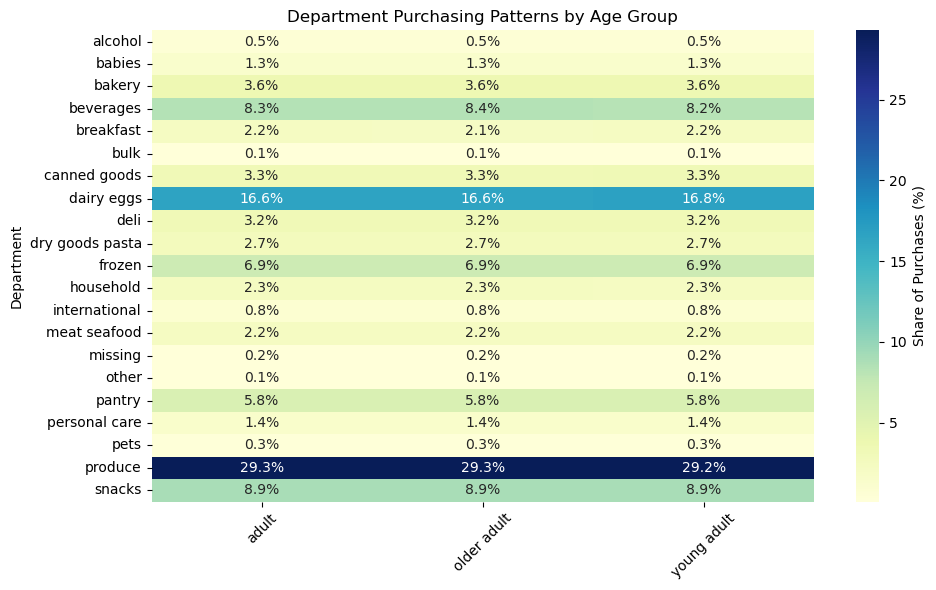

In [198]:
# Plotting heatmap
plt.figure(figsize=(10, 6)) 
ax = sns.heatmap(
    heatmap_data_age_dept,
    annot=heatmap_data_age_dept.map(lambda x: f'{x:.1f}%'), # Actual values
    fmt='',
    cmap='YlGnBu'
)

# Colorbar label
ax.collections[0].colorbar.set_label('Share of Purchases (%)')

# Labels
plt.title('Department Purchasing Patterns by Age Group')
plt.xlabel('')
plt.ylabel('Department')

plt.xticks(rotation=45)
plt.yticks(rotation=0)                                      
plt.tight_layout()

# Saving figure
plt.savefig(os.path.join(path, '04 Insights & Visualizations', 'percentage_heatmap_age_dept.png'), bbox_inches='tight')

### <u>**Age Does Not Strongly Differentiate Purchasing Behavior**
Department purchasing patterns are remarkably consistent across **Young Adults (18–33)**, **Adults (34–65)**, and **Older Adults (66–81)**. The same departments account for similar shares of purchases across all three groups, with **Produce (\~29%), Dairy & Eggs (\~17%), Snacks (\~9%), and Beverages (\~8%)** consistently representing the largest shares.

> ***This suggests that age does not meaningfully differentiate department-level purchasing behavior in this dataset. As a result, behavioral features may provide greater value than age for identifying distinct customer segments.***

---

### **Income Distribution**

In [200]:
# Checking income distribution to make categories.
df_users['income'].describe()

count    206209.000000
mean      94632.852548
std       42473.786988
min       25903.000000
25%       59874.000000
50%       93547.000000
75%      124244.000000
max      593901.000000
Name: income, dtype: float64

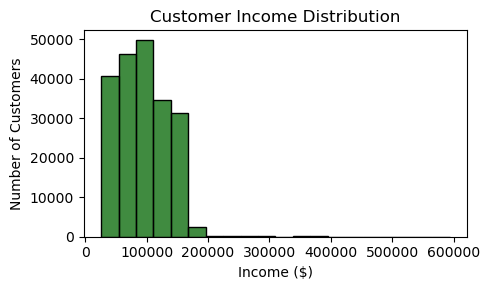

In [201]:
# Histogram - income distribution - checking natural break in data
plt.figure(figsize=(5,3))
income_hist = sns.histplot(df_users['income'], bins=20, edgecolor = 'black', color='darkgreen')
plt.title('Customer Income Distribution')
plt.xlabel('Income ($)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()      

#### **Income Distribution Is Right-Skewed**
While the median customer income sits at \\$93,547, the histogram shows a steep drop-off at \\$200,000, followed by an extreme long tail extending to the max income of \$593,901.

> ***To better capture this skewed distribution, a 4-tier income segmentation will be built to isolate earners above \$200,000 into an 'affluent income' category, while preserving lower, middle, and higher brackets for the rest of the customer base.***

In [202]:
# Bottom 25% of income. 
df_users.loc[df_users['income'] <= 60000, 'income_status'] = 'low income'

In [203]:
# 50% of data.
df_users.loc[(df_users['income'] > 60000) & (df_users['income'] < 125000), 'income_status'] = 'middle income'

In [204]:
# 75th percentile to the "break".
df_users.loc[(df_users['income'] >= 125000) & (df_users['income'] <= 200000), 'income_status'] = 'high income'

In [205]:
# Creating a fourth category - Ultra High Income (The extreme long tail)
df_users.loc[df_users['income'] > 200000, 'income_status'] = 'affluent income'

In [206]:
# Checking for nulls.
df_users['income_status'].value_counts(dropna=False)

income_status
middle income      103681
low income          51784
high income         49740
affluent income      1004
Name: count, dtype: int64

In [207]:
# Proportion of customers by income status. 
cust_by_income = df_users['income_status'].value_counts(normalize=True)*100
cust_by_income

income_status
middle income      50.279571
low income         25.112386
high income        24.121159
affluent income     0.486885
Name: proportion, dtype: float64

#### Customers are distributed primarily across **middle income (50.3%)**, **low income (25.1%)**, and **high income (24.1%) tiers**, while the **affluent income** segment represents approximately **0.5%** of customers.

> ***The affluent segment was deliberately isolated from the high income bracket because their purchasing behaviors, basket sizes, and product preferences may differ from each other. Separating this group allows subsequent analyses to evaluate whether affluent customers exhibit distinct shopping patterns without diluting insights from the broader high income segment.***

---

### **Household Composition (Family Status  & Number of Dependents)**
To better understand household dynamics, this section evaluates the relationship between **family status, number of dependents, and age**. Analyzing these variables together can provide insight into customers' household composition to help create behaviorally meaningful and distinct customer segments.

In [208]:
# Checking overview of 'fam_status' categories.
df_users['fam_status'].value_counts(dropna=False, normalize=True)*100

fam_status
married                             70.271424
single                              16.469698
divorced/widowed                     8.554428
living with parents and siblings     4.704450
Name: proportion, dtype: float64

#### Family Status by Number of Dependents 

In [209]:
# Checking 'fam_status' and number of dependents - what percentage of each group has dependents?
fam_and_dependents = pd.crosstab(df_users['fam_status'], df_users['n_dependents'], dropna = False, normalize='index')*100
fam_and_dependents

n_dependents,0,1,2,3
fam_status,,,,
divorced/widowed,100.0,0.000000,0.000000,0.000000
living with parents and siblings,0.0,33.233687,33.584167,33.182146
married,0.0,33.336784,33.279505,33.383711
single,100.0,0.000000,0.000000,0.000000


### <u> **Family Status Strongly Aligns With Household Structure** </u>
- All **divorced/widowed** and **single customers** have **0 dependents**, indicating these groups primarily represent smaller households.
- In contrast, all **married customers** and those **living with parents and siblings** consistently **have 1-3 dependents**, reflecting larger household structures. 

#### Family Status by Age

In [210]:
# Checking 'fam_status' and age.
fam_and_age = pd.crosstab(df_users['fam_status'], df_users['age_status'], dropna = False, normalize='index')*100
fam_and_age

age_status,adult,older adult,young adult
fam_status,,,
divorced/widowed,27.148526,72.851474,0.000000
living with parents and siblings,0.000000,0.000000,100.000000
married,53.254524,26.729742,20.015734
single,61.860314,0.000000,38.139686


### <u> **Family Status and Age Define Distinct Customer Profiles** </u>
- Customers **living with parents and siblings** are **exclusively classified as young adults aged 18–33**.
- **Single** customers are concentrated among **young adults (18-33) and those aged 34-65**, with **no customers aged 66 and older**, indicating that  this segment is concentrated among **younger age groups**.
- All **divorced/widowed** customers are **over 33 years of age**, with approximately **73% classified as older adults (66-81)**, reflecting a later-life household profile.
- **Married customers** demonstrate the broadest age distribution, **spanning all three age groups**, with the **majority (53.2%) aged 34-65**.

---

### Creating Household Categories (Descriptive Segmentation)
The strong alignment between **age and number of dependents** provides a basis for combining these characteristics into a `household_status` variable, allowing customers to be grouped into more behaviorally meaningful profiles that reflect **different household compositions and potential purchasing needs**.

In [211]:
# Combining age and number of dependents - Creating single (no dependents) vs. family (with dependents) customer profiles.

# Defining conditions.
conditions = [
    (df_users['age'] <= 33) &
    (df_users['n_dependents'] == 0),

    (df_users['age'] <= 33) &
    (df_users['n_dependents'] >= 1),

    (df_users['age'].between(34, 65)) &
    (df_users['n_dependents'] == 0),

    (df_users['age'].between(34, 65)) &
    (df_users['n_dependents'] >= 1),

    (df_users['age'] >= 66) &
    (df_users['n_dependents'] == 0),

    (df_users['age'] >= 66) &
    (df_users['n_dependents'] >= 1)
]

choices = [
    'young single',
    'young family',
    'adult single',
    'adult family',
    'older single',
    'older family'
]

# Applying the vectorized logic.
df_users['household_status'] = np.select(conditions, choices, default='Other')


In [212]:
# Checking for nulls and counts.
df_users['household_status'].value_counts(dropna=False)

household_status
adult family    77169
older family    38733
young family    38705
adult single    25798
young single    12953
older single    12851
Name: count, dtype: int64

In [213]:
# Proportion of customers by household category.
df_users['household_status'].value_counts(dropna=False, normalize=True)*100

household_status
adult family    37.422712
older family    18.783370
young family    18.769792
adult single    12.510608
young single     6.281491
older single     6.232027
Name: proportion, dtype: float64

### <u> **Household Distribution: 75% Families vs. 25% Single Adults**
- **Young, adult, and older family categories** account for approximately **75% of the customer base**, with **adult families (ages 34–65 with dependents)** forming the **largest household segment** at **37.4%**.
- **Young and older family households** are similarly represented, **each accounting for ~18.8% of customers**.
- **Single households** make up the remaining **25% of customers**, with **adult singles (ages 34–65 without dependents)** accounting for **12.5%**, while **young and older singles each represent approximately 6%**.
  
> ***These household categories provide a behavioral foundation for customer segmentation by capturing differences in household composition that may be associated with distinct purchasing needs and shopping patterns.***

### **Household & Department Preferences**
Do families vs. singles favor different departments?

In [214]:
# Creating a small analysis dataframe for household-level purchasing patterns
household_dept_data = df_order_behavior[['user_id', 'department']].merge(
    df_users[['user_id', 'household_status']],
    on='user_id',
    how='left'
)

In [215]:
# Counting product purchases by household status and department
household_dept = (
    household_dept_data
    .groupby(['household_status', 'department'], observed=True)
    .size()
    .reset_index(name='purchase_count')
)

In [216]:
# Calculating percentage within each household status
household_dept['purchase_pct'] = (
    household_dept['purchase_count']
    / household_dept.groupby('household_status')['purchase_count'].transform('sum')
    * 100
)

In [217]:
# Making crosstab
crosstab_fam_dept_pct = household_dept.pivot(
    index='department',
    columns='household_status',
    values='purchase_pct'
)

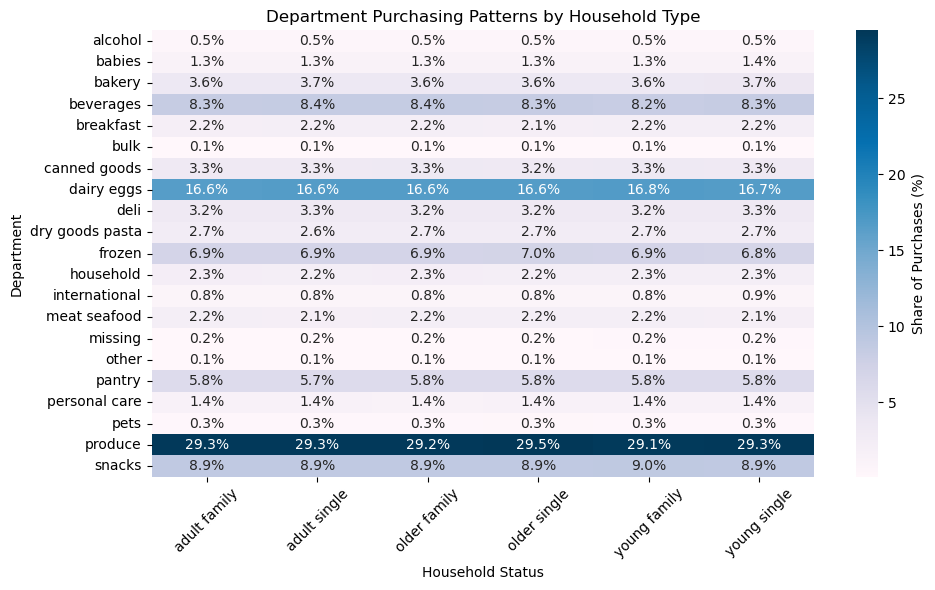

In [218]:
# Plotting heatmap
plt.figure(figsize=(10, 6))

ax_2 = sns.heatmap(
    crosstab_fam_dept_pct,
    cmap='PuBu',
    annot=crosstab_fam_dept_pct.map(lambda x: f'{x:.1f}%'),
    fmt=''
)

# Colorbar label
ax_2.collections[0].colorbar.set_label('Share of Purchases (%)')

# Labels
plt.title('Department Purchasing Patterns by Household Type')
plt.ylabel('Department')
plt.xlabel('Household Status')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

# Saving figure
plt.savefig(os.path.join(path, '04 Insights & Visualizations', 'pct_heatmap_household_dept.png'), bbox_inches='tight')

### <u>**Department Preferences Are Consistent Across Household Profiles**
- Much like age, **household composition shows limited differentiation in department-level purchasing behavior.**. Across all household profiles, customers exhibit remarkably similar department mixes, with **Produce, Dairy & Eggs, Snacks, and Beverages** consistently accounting for the largest shares.
- **This suggests that household type alone does not meaningfully differentiate department-level purchasing behavior in this dataset.**

> ***Household type may provide useful context for understanding customers, but it appears to have limited value as a primary segmentation variable. This reinforces the focus on behavioral features such as, spend tier, basket size, and order frequency to identify more meaningful customer segments.***

---

## <div style = 'background-color: thistle '> <center> <font color='rebeccapurple'>**5. User‑Level Feature Engineering**</font> </div>
To further develop meaningful customer segments, transactional order data is transformed into **customer-level behavioral features** that capture **shopping behavior, spending patterns, and basket characteristics**. Together, these features summarize each customer's purchasing habits into a **behavioral profile** to provide the quantitative inputs for the **rule-based segmentation logic developed in Section 6**.

### User-Level Flags
Creating user-level flags based on the columns `num_of_orders`, `avg_spend_per_order`, and`avg_days_between_orders`.

In [223]:
# 1. Order-level table
order_table = df_order_behavior[[
    'order_id', 'user_id', 'order_number', 'days_since_prior_order', 
    'order_total_items', 'total_order_spend'
]].drop_duplicates(subset='order_id')

In [224]:
# 2. Grouping by 'user_id'
users_orders_subset = order_table.groupby('user_id').agg(
    max_order_num=('order_number', 'max'),                 # Max. number of orders 
    avg_items_per_order=('order_total_items', 'mean'),             # Average items per order
    avg_spend_per_order=('total_order_spend', 'mean'),   # Average of total spend per order
    avg_days_between_orders=('days_since_prior_order', 'mean') # Average order frequency
).reset_index()

In [225]:
users_orders_subset.head()

,user_id,max_order_num,avg_items_per_order,avg_spend_per_order,avg_days_between_orders
0,1,10,5.900000,37.570000,19.555556
1,2,14,13.928571,104.685714,15.230769
2,3,12,7.333333,60.116667,12.090909
3,4,5,3.600000,29.540000,13.750000
4,5,4,9.250000,85.000000,13.333333


In [226]:
# 3. Pulling the summary stats to build flags.
print(users_orders_subset[['max_order_num', 'avg_spend_per_order', 'avg_days_between_orders']].describe())

       max_order_num  avg_spend_per_order  avg_days_between_orders
count  206209.000000        206209.000000            206208.000000
mean       15.590256            77.521454                15.209365
std        16.654823            46.489379                 7.105439
min         1.000000             1.000000                 0.000000
25%         5.000000            43.880000                 9.416667
50%         9.000000            69.751852                14.500000
75%        19.000000           101.962500                20.285714
max        99.000000           548.725000                30.000000


### **Engagement Status**
Categorizes customer engagement levels for each unique user's total number of orders placed (`max_order_num`).

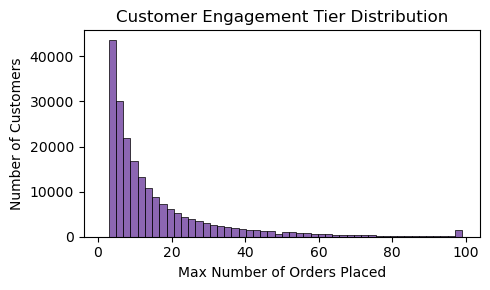

In [227]:
# Histogram - engagement distribution - checking natural break in data to make accurate tiers
plt.figure(figsize=(5,3))
max_order_hist = sns.histplot(users_orders_subset['max_order_num'], bins=50, color='rebeccapurple')
plt.title('Customer Engagement Tier Distribution')
plt.xlabel('Max Number of Orders Placed')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()      

In [228]:
# Creating engagement flags based on distribution of 'num_of_orders' columns (MAX ORDERS). 
# Bottom 25%.
users_orders_subset.loc[users_orders_subset['max_order_num'] <= 5, 'engagement_status'] = 'low engagement'

In [229]:
# Established customer (middle 50%).
users_orders_subset.loc[(users_orders_subset['max_order_num'] > 5) & (users_orders_subset['max_order_num'] <= 19), 'engagement_status'] = 'moderate engagement'

In [230]:
# Upper to break. 
users_orders_subset.loc[(users_orders_subset['max_order_num'] > 19) & (users_orders_subset['max_order_num'] <= 30), 'engagement_status'] = 'high engagement'

In [231]:
# Heavy users (top-tier).
users_orders_subset.loc[users_orders_subset['max_order_num'] > 30, 'engagement_status'] = 'elite engagement'

In [232]:
# Checking all activity was flagged.
users_orders_subset['engagement_status'].value_counts(dropna=False)

engagement_status
moderate engagement    95735
low engagement         59743
elite engagement       27709
high engagement        23022
Name: count, dtype: int64

In [233]:
# User-level - this finds the proportion of customers by engagement status 
cust_by_engagement = users_orders_subset['engagement_status'].value_counts(normalize=True)*100
cust_by_engagement

engagement_status
moderate engagement    46.426199
low engagement         28.972062
elite engagement       13.437338
high engagement        11.164401
Name: proportion, dtype: float64

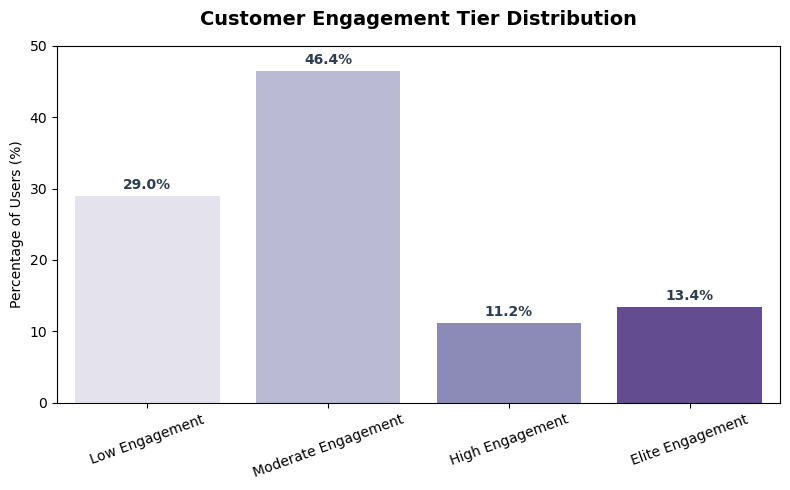

In [234]:
# 1. Ordering 
ordered_tiers = ['low engagement', 'moderate engagement', 'high engagement', 'elite engagement']
ordered_values = [cust_by_engagement[tier] for tier in ordered_tiers]

# 2. Labels
display_labels = ['Low Engagement', 'Moderate Engagement', 'High Engagement', 'Elite Engagement']

# 3. Plot 
plt.figure(figsize=(8, 5))

engagement_bars = sns.barplot(
    x=display_labels,          
    y=ordered_values,         
    palette= 'Purples',   
    hue=display_labels,        
    legend=False                   
)

plt.title('Customer Engagement Tier Distribution', fontsize=14, weight='bold', pad=15)
plt.ylabel('Percentage of Users (%)')
plt.xlabel('')
plt.xticks(rotation=20)
plt.ylim(0, 50)

# Adding labels on bars
for i, v in enumerate(ordered_values):
    plt.text(i, v + 1.0, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=10, color='#2c3e50')

plt.tight_layout()
plt.show()

### **Most Customers Demonstrate Repeat Purchasing Behavior**
- **Moderate Engagement** customers represent the largest segment (**46.4%**), placing **6-19 orders**, while **High** and **Elite Engagement** customers together accounting for **nearly a quarter** of the customer base (**24.6%**).
- **Over 70%** of customers fall outside the **Low Engagement** tier (**5 orders or fewer**), demonstrating that **repeat purchasing is common across the platform rather than being limited to a small group of highly engaged customers**.
- The **Elite Engagement** tier (**over 30 orders**) represents **13.4%** of customers, slightly exceeding the **High Engagement** tier (**20-30 orders**) at **11.2%**, indicating that a meaningful subset of customers exhibit **sustained long-term purchasing activity**.

> ***These engagement tiers provide a useful behavioral dimension for segmentation, distinguishing customers by their level of repeat purchasing and overall shopping engagement.***

In [235]:
# Exporting visual
engagement_bars.figure.savefig(os.path.join(path, '04 Insights & Visualizations', 'cust_engagement_tiers.png'), dpi=300, bbox_inches='tight')

---

### **Order Frequency**
Categorizes each customer's order frequency based on the distribution of the `avg_days_between_orders`, a customer-level feature derived from the `days_since_prior_order` column.

In [237]:
# Bottom 25% (less than 10 orders to cover 9.4).
users_orders_subset.loc[users_orders_subset['avg_days_between_orders'] < 10, 'order_freq_status'] = 'active shopper'

In [238]:
# Middle 50% - most users 
users_orders_subset.loc[(users_orders_subset['avg_days_between_orders'] >= 10) & (users_orders_subset['avg_days_between_orders'] <20 ), 'order_freq_status'] = 'regular shopper'

In [239]:
# 75th percentile (before a customer reaches 3 weeks without an order).
users_orders_subset.loc[users_orders_subset['avg_days_between_orders'] >= 20, 'order_freq_status'] = 'occasional shopper'

In [240]:
# Checking for nulls. 
users_orders_subset['order_freq_status'].value_counts(dropna=False)

order_freq_status
regular shopper       94670
active shopper        56939
occasional shopper    54599
NaN                       1
Name: count, dtype: int64

In [241]:
# Checking the 1 null
users_orders_subset.loc[
    users_orders_subset['order_freq_status'].isna()
].T

,159837
user_id,159838
max_order_num,1
avg_items_per_order,5.0
avg_spend_per_order,37.1
avg_days_between_orders,NaN
engagement_status,low engagement
order_freq_status,NaN


<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;">
         This null is expected as it belongs to a user that has only placed one order and was classified separately as a One-Time Shopper because no repeat-purchase interval could be calculated.
    </p>


In [242]:
# Making a fourth category for this one user 
users_orders_subset.loc[
    users_orders_subset['max_order_num'] == 1,
    'order_freq_status'
] = 'one-time shopper'

In [243]:
# Checking for nulls again
users_orders_subset['order_freq_status'].value_counts(dropna=False)

order_freq_status
regular shopper       94670
active shopper        56939
occasional shopper    54599
one-time shopper          1
Name: count, dtype: int64

In [244]:
# Proportion of users by shopping frequency.
cust_by_freq = users_orders_subset['order_freq_status'].value_counts(dropna=False, normalize=True)*100 
cust_by_freq

order_freq_status
regular shopper       45.909732
active shopper        27.612277
occasional shopper    26.477506
one-time shopper       0.000485
Name: proportion, dtype: float64

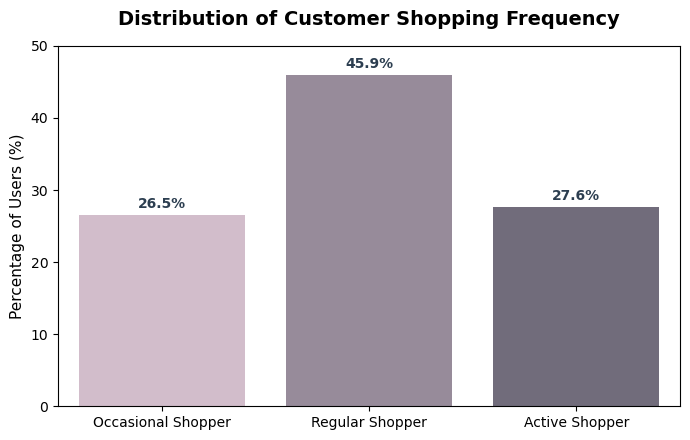

In [245]:
# 1. Setting order
ordered_freq = [ 'occasional shopper', 'regular shopper', 'active shopper']
ordered_freq_values = [cust_by_freq[status] for status in ordered_freq]

# 2. Labels
display_labels = ['Occasional Shopper', 'Regular Shopper', 'Active Shopper']
label = '<0.1%' if v < 0.05 else f'{v:.1f}%'

# 3. Customer colors
colors = ['#d6b9cc', '#98899c', '#70697e']

# 4. Plot 
plt.figure(figsize=(7, 4.5))

cust_freq_bars = sns.barplot(
    x=display_labels,          
    y=ordered_freq_values,         
    palette=colors,    
    hue=display_labels,        
    legend=False                   
)

# 5. Labels, etc. 
plt.title('Distribution of Customer Shopping Frequency' , fontsize=14, weight='bold', pad=15)
plt.ylabel('Percentage of Users (%)', fontsize=11)
plt.xlabel('')
plt.ylim(0, 50) 

# 6. Adding labels to bars
for i, v in enumerate(ordered_freq_values):
    plt.text(i, v + 1.0, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=10, color='#2c3e50')

plt.tight_layout()
plt.show()

<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;">
         <strong> One customer placed only one order and was classified as a One-Time Shopper because no repeat-purchase interval could be calculated. This category represents less than 0.00% of customers and is excluded from the visualization.</strong>
    </p>

### **Nearly 46% of Customers Place a Subsequent Order every 10-19 Days**
- **Regular Shoppers** represent the largest segment (**45.9%**) and maintain a consistent purchasing cadence, **placing orders approximately every 10–19 days**.
- **Active Shoppers** account for **27.6%** of customers with the shortest purchase intervals (**less than 10 days between orders**), exhibiting the most frequent shopping behavior.
    - **Combined, these tiers account for 73.5%** of customers, suggesting that the **majority of users demonstrate recurring purchasing behavior** rather than infrequent shopping patterns.
- **Occasional Shoppers** represent **26.5%** of customers and have longer purchase intervals (**20+ days between orders**), highlighting an opportunity to understand the behaviors that differentiate infrequent shoppers from more consistent repeat customers.

> ***Order frequency provides a complementary behavioral dimension to engagement, distinguishing customers by purchase cadence and repeat timing rather than total order history alone.***

In [246]:
# Exporting visual
cust_freq_bars.figure.savefig(os.path.join(path, '04 Insights & Visualizations', 'cust_shopping_freq.png'), dpi=300, bbox_inches='tight')

---

### **Spend Status**
Categorizes customers based on their `avg_spend_per_order`. This user-level metric was calculated by aggregating product-level prices from the `price` column across each customer's unique orders, to capture **differences in average purchasing value between customers**.

In [247]:
users_orders_subset['avg_spend_per_order'].describe()

count    206209.000000
mean         77.521454
std          46.489379
min           1.000000
25%          43.880000
50%          69.751852
75%         101.962500
max         548.725000
Name: avg_spend_per_order, dtype: float64

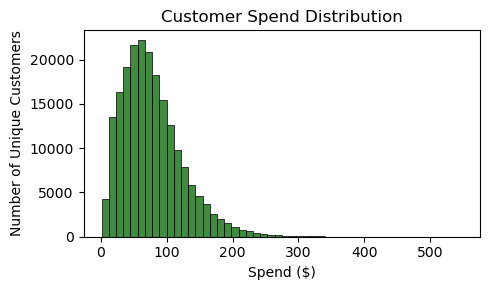

In [248]:
# Histogram - customer spend distribution - checking natural break in data
plt.figure(figsize=(5,3))
cust_spend_hist = sns.histplot(users_orders_subset['avg_spend_per_order'], bins=50, color='darkgreen')
plt.title('Customer Spend Distribution')
plt.xlabel('Spend ($)')
plt.ylabel('Number of Unique Customers')
plt.tight_layout()
plt.show()  

In [249]:
# Bottom 25%.
users_orders_subset.loc[users_orders_subset['avg_spend_per_order'] < 44, 'spend_status'] = 'low spender'

In [250]:
# Middle 50%.
users_orders_subset.loc[(users_orders_subset['avg_spend_per_order'] >= 44) &
                        (users_orders_subset['avg_spend_per_order'] < 102), 'spend_status'] = 'moderate spender'

In [251]:
# 75th percentile to natural break.
users_orders_subset.loc[(users_orders_subset['avg_spend_per_order'] >= 102) & 
                        (users_orders_subset['avg_spend_per_order'] < 200), 'spend_status'] = 'high spender'

In [252]:
# Top-tier spenders. 
users_orders_subset.loc[users_orders_subset['avg_spend_per_order'] >= 200, 'spend_status'] = 'premium spender'

In [253]:
# Checking for nulls.
users_orders_subset['spend_status'].value_counts(dropna=False)

spend_status
moderate spender    102934
low spender          51766
high spender         47593
premium spender       3916
Name: count, dtype: int64

In [254]:
cust_by_spend = users_orders_subset['spend_status'].value_counts(dropna=False, normalize=True) * 100
cust_by_spend

spend_status
moderate spender    49.917317
low spender         25.103657
high spender        23.079982
premium spender      1.899044
Name: proportion, dtype: float64

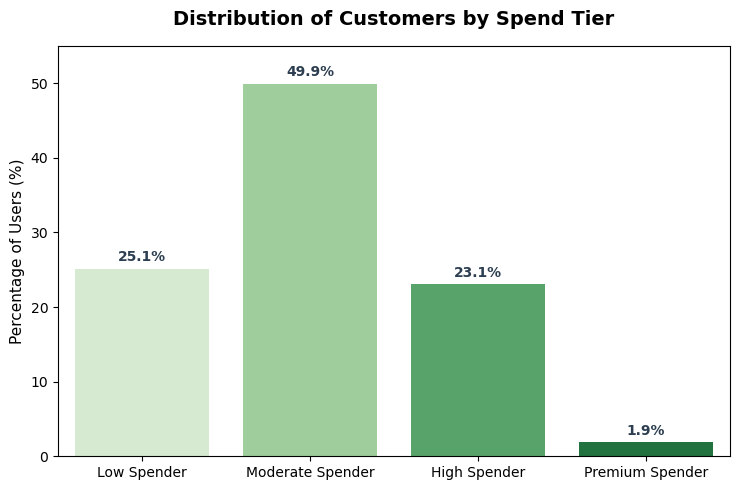

In [255]:
# 1.Order (low to high)
cust_spend_order = ['low spender', 'moderate spender', 'high spender', 'premium spender']
ordered_spend_values = [cust_by_spend[status] for status in cust_spend_order]

# 2. Labels
display_labels = ['Low Spender', 'Moderate Spender', 'High Spender', 'Premium Spender']

# 3. Colors
colors = sns.color_palette('Greens', n_colors=len(ordered_spend_values))

# 4. Plot
plt.figure(figsize=(7.5, 5))

cust_spend_bars = sns.barplot(
    x=display_labels,          
    y=ordered_spend_values,         
    palette=colors,    
    hue=display_labels,        
    legend=False                   
)

# 6. Labels, etc. 
plt.title('Distribution of Customers by Spend Tier', fontsize=14, weight='bold', pad=15)
plt.ylabel('Percentage of Users (%)', fontsize=11)
plt.xlabel('')
plt.ylim(0, 55) 

# 7. Adding labels to bars
for i, v in enumerate(ordered_spend_values):
    plt.text(i, v + 1.0, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=10, color='#2c3e50')

plt.tight_layout()
plt.show()

### **Approximately 50% of Customers Fall Within Moderate Spending Levels**
- **Moderate Spenders** form the dominant customer segment, accounting for nearly half of all users (**49.9%**) with an **average spend per order** between **\\$44 and \\$101**.
- **Low and High Spenders** account for most of the remaining customers, representing **25.1%** and **23.1% respectively**.
- **Premium Spenders** represent a small but distinct segment (**1.9%**), with an **average spend per order exceeding \\$200** and reaching a maximum of **\\$548**. While limited in size, this group represents the **highest-value purchasing behavior** on the platform and **may exhibit distinct product preferences or shopping patterns**.
  
> ***Spend status adds a monetary dimension to order frequency and engagement, further distinguishing customers and creating more complete behavioral profiles for customer segmentation.***

In [256]:
# Exporting visual
cust_spend_bars.figure.savefig(os.path.join(path, '04 Insights & Visualizations', 'cust_spend_tier.png'), dpi=300, bbox_inches='tight')

---

### **Spend Tier Behavior**

#### Total Spend per Spend Tier

In [259]:
users_orders_subset.columns

Index(['user_id', 'max_order_num', 'avg_items_per_order',
       'avg_spend_per_order', 'avg_days_between_orders', 'engagement_status',
       'order_freq_status', 'spend_status'],
      dtype='object')

In [260]:
# 1. Aggregating total order spend per user ID.
user_total_spend = order_table.groupby('user_id')['total_order_spend'].sum() 

In [261]:
# 2. Mapping column to user-level table. 
users_orders_subset['total_spend'] = users_orders_subset['user_id'].map(user_total_spend)

#### Spend Share by Spend Tier

In [262]:
# 1. Calculating total revenue across the whole platform.
platform_total_revenue = order_table['total_order_spend'].sum()


# 2. Summing total spend by tier, then dividing by total revenue (of platform), converting to percentage, and sorting highest to lowest. 
revenue_by_spend_tier = (
    users_orders_subset.groupby('spend_status')['total_spend']
    .sum()  
    .div(platform_total_revenue)
    .mul(100)
    .sort_values(ascending=False)
)

print(revenue_by_spend_tier)

spend_status
moderate spender    48.061564
high spender        39.031974
low spender          8.070664
premium spender      4.835798
Name: total_spend, dtype: float64


#### Spend Tier by Engagement (number of orders)

In [263]:
spend_tier_engagement = pd.crosstab(users_orders_subset['engagement_status'],
            users_orders_subset['spend_status'],
            normalize='index') * 100
spend_tier_engagement

spend_status,high spender,low spender,moderate spender,premium spender
engagement_status,,,,
elite engagement,23.916417,19.087661,55.530694,1.465228
high engagement,23.890192,21.470767,52.753888,1.885153
low engagement,21.898800,29.369131,46.510888,2.221181
moderate engagement,23.380164,25.056667,49.736251,1.826918


#### Spend Tier by Order Frequency

In [264]:
spend_tier_freq = pd.crosstab(users_orders_subset['order_freq_status'],
            users_orders_subset['spend_status'],
            normalize='index') * 100
spend_tier_freq

spend_status,high spender,low spender,moderate spender,premium spender
order_freq_status,,,,
active shopper,22.552205,22.151776,53.703086,1.592933
occasional shopper,22.498581,30.348541,44.878111,2.274767
one-time shopper,0.000000,100.000000,0.000000,0.000000
regular shopper,23.732967,23.853385,50.547164,1.866484


### <u> **Moderate Spenders Are The Economic Core of The Platform** </u>
- **Moderate Spenders** represent approximately half of the customer base, dominate every engagement and order frequency tier, and drive a proportional **48% of total estimated spend**.
- **High Spenders** represent **23.1%** of customers but generate **39% of overall spend**, making them a **disproportionately valuable customer  segment**.
- Although **Premium Spenders have the highest average spend per order,**, **Low Spenders** actually **contribute more total spend (8.1% vs. 4.8% respectively)** since they make up a larger share of the customer base.

> ***Together, these findings show that customer value is shaped not only by how much customers spend per order, but also by their shopping frequency and engagement, providing a strong foundation for behaviorally meaningful customer segmentation.***

#### Spend Tier by Basket Size

In [265]:
user_total_orders = order_table.groupby('user_id')['order_total_items'].sum() 
users_orders_subset['total_items'] = users_orders_subset['user_id'].map(user_total_orders)

In [266]:
# 1. Group by your spend tier and sum up the true pools of items and orders
total_items_orders = users_orders_subset.groupby('spend_status')[['total_items', 'max_order_num']].sum()

# 2. Divide the total items pool by the total orders pool to get the true average
total_items_orders['true_avg_basket_size'] = total_items_orders['total_items'] / total_items_orders['max_order_num']

print(total_items_orders['true_avg_basket_size'].sort_values(ascending=False))

spend_status
premium spender     29.749493
high spender        16.776166
moderate spender     9.092509
low spender          3.962189
Name: true_avg_basket_size, dtype: float64


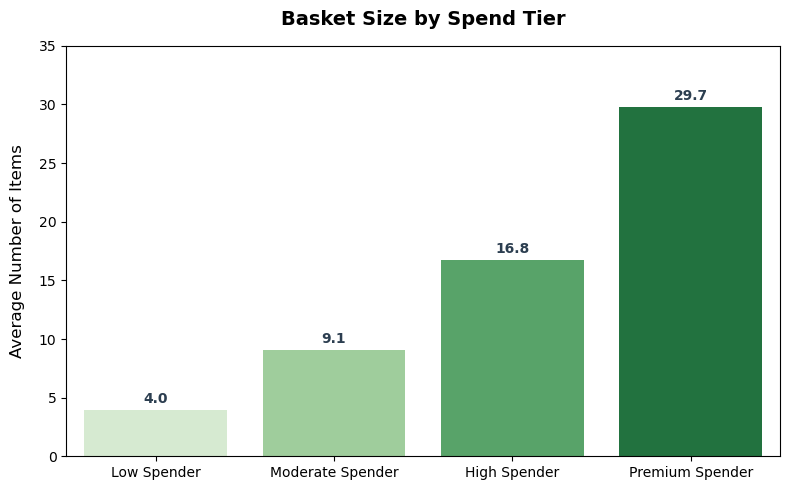

In [268]:
# 1. Order tiers and extract actual basket size numbers correctly using .loc
tier_order = ['low spender', 'moderate spender', 'high spender', 'premium spender']
ordered_num_items = [total_items_orders.loc[tier, 'true_avg_basket_size'] for tier in tier_order]

# 2. Colors
colors = sns.color_palette('Greens', n_colors=len(ordered_num_items))

display_labels = ['Low Spender', 'Moderate Spender', 'High Spender', 'Premium Spender']

# 3. Plot
plt.figure(figsize=(8, 5))

basket_size_spend_tier = sns.barplot(
    x=display_labels, 
    y=ordered_num_items, 
    palette=colors,    
    hue=display_labels,        
    legend=False       
)

# 4. Titles & Labels
plt.title('Basket Size by Spend Tier', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('', fontsize=12, labelpad=10)
plt.ylabel('Average Number of Items', fontsize=12, labelpad=10)

# Set dynamic y-limit with breathing room above max value
max_val = max(ordered_num_items)
plt.ylim(0, 35) 

# 5. Add data labels above bars (formatted as decimal numbers, not percentages)
for i, v in enumerate(ordered_num_items):
    plt.text(i, v + (max_val * 0.02), f"{v:.1f}", ha='center', fontweight='bold', fontsize=10, color='#2c3e50')

plt.tight_layout()
plt.show()

### **Higher-Spending Customers Build Larger Baskets** 
- **Average basket size increases consistently across spend tiers**, indicating that higher-spending customers tend to build larger baskets.
- **Low Spenders** not only **take more time between orders**, but also purchase relatively few items **averaging approximately 4 items per order**.
- **Premium Spenders** build the largest baskets, **averaging nearly 30 items per order (29.7)**, which is roughly **3x** the size of **Moderate Spender baskets (9.1 items)** and **over 7x** larger than **Low Spender baskets**.
- Combined with the earlier order frequency analysis, these findings suggest that **Premium Spenders** tend to place **less frequent but substantially larger orders**, consistent with **stock-up shopping behavior** rather than routine replenishment.


> ***The product mix of Premium Spenders is examined in later sections to better understand the shopping behaviors associated with their substantially larger baskets compared with Low Spenders.***


In [269]:
# Exporting visual
basket_size_spend_tier.figure.savefig(os.path.join(path, '04 Insights & Visualizations', 'basket_size_spend_tier.png'), dpi=300, bbox_inches='tight')

---

### **Spend Behavior & Demographics**
This section examines whether **age, household composition, and income differ across spend tiers**, helping determine whether **customer value is primarily associated with demographic characteristics or behavioral purchasing patterns**.



#### Creating a Master User-Level Table (Merging User Tables)

In [271]:
df_users.columns

Index(['user_id', 'gender', 'state', 'age', 'n_dependents', 'fam_status',
       'income', 'region', 'age_status', 'income_status', 'household_status'],
      dtype='object')

In [272]:
users_orders_subset.columns

Index(['user_id', 'max_order_num', 'avg_items_per_order',
       'avg_spend_per_order', 'avg_days_between_orders', 'engagement_status',
       'order_freq_status', 'spend_status', 'total_spend', 'total_items'],
      dtype='object')

In [273]:
# 1. Merging the user demographics table with user-level behavior table. 
df_user_master = df_users.merge(users_orders_subset, on='user_id', how='inner')

In [274]:
df_user_master.shape

(206209, 20)

In [275]:
# Data overview
master_check = df_user_master.head()
master_check

,user_id,gender,state,age,n_dependents,fam_status,income,region,age_status,income_status,household_status,max_order_num,avg_items_per_order,avg_spend_per_order,avg_days_between_orders,engagement_status,order_freq_status,spend_status,total_spend,total_items
0,202279,Male,Idaho,57,3,married,98119,West,adult,middle income,adult family,8,11.250000,96.962500,21.571429,moderate engagement,occasional shopper,moderate spender,775.7,90.0
1,205970,Male,Oregon,43,2,married,149831,West,adult,high income,adult family,25,12.920000,112.168000,9.208333,high engagement,active shopper,high spender,2804.2,323.0
2,178520,Male,Maine,71,2,married,76976,Northeast,older adult,middle income,older family,56,16.482143,134.378571,6.490909,elite engagement,active shopper,high spender,7525.2,923.0
3,156122,Male,Georgia,35,3,married,80419,South,adult,middle income,adult family,52,18.596154,141.819231,6.705882,elite engagement,active shopper,high spender,7374.6,967.0
4,22352,Male,Illinois,30,2,married,88210,Midwest,young adult,middle income,young family,8,11.375000,91.912500,23.714286,moderate engagement,occasional shopper,moderate spender,735.3,91.0


#### Age and Household Status vs. Spend Tiers

In [276]:
spend_tier_house = pd.crosstab(df_user_master['spend_status'], df_user_master['household_status'], normalize='index') * 100
spend_tier_house

household_status,adult family,adult single,older family,older single,young family,young single
spend_status,,,,,,
high spender,37.618978,12.361062,18.723342,6.274032,18.859916,6.162671
low spender,37.447359,12.705251,18.651238,6.172005,18.668624,6.355523
moderate spender,37.349175,12.485670,18.875202,6.263237,18.749879,6.276838
premium spender,36.644535,12.410623,18.845761,5.694586,19.535240,6.869254


In [277]:
spend_tier_age = pd.crosstab(df_user_master['spend_status'], df_user_master['age_status'], normalize='index') * 100
spend_tier_age

age_status,adult,older adult,young adult
spend_status,,,
high spender,49.980039,24.997374,25.022587
low spender,50.152610,24.823243,25.024147
moderate spender,49.834846,25.138438,25.026716
premium spender,49.055158,24.540347,26.404494


#### Income Status vs. Spend Tiers

In [278]:
spend_tier_income = pd.crosstab(df_user_master['spend_status'], df_user_master['income_status'], normalize='index') * 100
spend_tier_income

income_status,affluent income,high income,low income,middle income
spend_status,,,,
high spender,0.668165,27.863341,13.739415,57.729078
low spender,0.197041,17.339567,45.773287,36.690105
moderate spender,0.529465,25.639730,20.461655,53.369149
premium spender,0.995914,28.370787,12.461696,58.171604


### <u> **Behavioral Features Differentiate Spending More Than Demographics** </u>
- **Age and household composition show minimal variation across spend tiers**, with **similar distributions across all family and single household categories**, suggesting that **these variables alone are not strong differentiators of customer spending behavior**.
- **Income shows a clearer, but still limited, relationship with spending.**
    - **Middle Income customers make up the largest income group across every spend tier**, representing approximately **53%–58%** of customers within each tier.
    - **Low Spenders** are more concentrated among the **Low Income bracket (\$60k or less)**, accounting for **45.8% of this segment**.
    - **High and Premium Spenders** are primarily composed of **Middle and High Income (\\$61k–\$200k)** customers, which **collectively accounts for approximately 86% of these higher-spending segments**.
      
> ***These findings indicate that income provides useful context but does not fully explain differences in customer spending behavior, reinforcing the importance of behavioral variables such as spend, basket size, order frequency, and number of orders (engagement) when building customer segments.***


---

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 24px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
   <center>  Product Comparison: What Are Premium vs. Low Spend Tiers Buying? </h3>
    
To better understand average order value differences, this section analyzes **product mix across Premium and Low Spenders**. By finding which items are overrepresented in each tier, this can provide insight into how **basket composition** can affect the spend behaviors observed earlier.

#### Merging User-Level Data with Product Data

In [280]:
# Checking columns in master df. 
df_user_master.columns

Index(['user_id', 'gender', 'state', 'age', 'n_dependents', 'fam_status',
       'income', 'region', 'age_status', 'income_status', 'household_status',
       'max_order_num', 'avg_items_per_order', 'avg_spend_per_order',
       'avg_days_between_orders', 'engagement_status', 'order_freq_status',
       'spend_status', 'total_spend', 'total_items'],
      dtype='object')

In [281]:
# Checking columns in order data - product_id level
df_order_behavior.columns

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id',
       'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'is_first_order', 'product_name', 'aisle_id',
       'department_id', 'price', 'department', 'gender', 'state', 'age',
       'date_joined', 'n_dependents', 'fam_status', 'income', 'merge_check',
       'time_block', 'order_total_items', 'basket_size', 'total_order_spend',
       'order_value', 'product_price_tier', 'week_split'],
      dtype='object')

In [282]:
# 1. Selecting only necessary columns from product-level df
prod_filtered = df_order_behavior[['order_id', 'product_id', 'user_id', 'order_number', 'product_name', 'department']]

# 2. Filtering df_user_master table - premium and low spenders only
prem_low_spenders = df_user_master[df_user_master['spend_status'].isin(['premium spender', 'low spender'])][["user_id", "spend_status"]]

# 3. Merging the two - inner join to only match rows belonging to premium and low spenders
prem_low_lift = prod_filtered.merge(prem_low_spenders, on="user_id", how="inner")

In [283]:
prem_low_lift.head()

,order_id,product_id,user_id,order_number,product_name,department,spend_status
0,7,34050,142903,11,Orange Juice,beverages,low spender
1,7,46802,142903,11,Pineapple Chunks,frozen,low spender
2,8,23423,3107,5,Original Hawaiian Sweet Rolls,bakery,low spender
3,16,9755,174840,18,Original Popcorn,snacks,low spender
4,16,25466,174840,18,Water,beverages,low spender


---

### Calculating Product Lift (Premium vs. Low Spenders)
Among products that are commonly purchased by both groups, which ones distinguish them?

In [284]:
# 1. Raw purchase counts - PREMIUM vs. LOW
premium_counts = (
    prem_low_lift.loc[
        prem_low_lift['spend_status'] == 'premium spender',
        'product_name'
    ]
    .value_counts()
)

low_counts = (
    prem_low_lift.loc[
        prem_low_lift['spend_status'] == 'low spender',
        'product_name'
    ]
    .value_counts()
)

In [285]:
# 2. Converting counts to shares
premium_shares = premium_counts / premium_counts.sum()
low_shares = low_counts / low_counts.sum()

In [286]:
# 3. Combining counts and shares
prem_low_table = pd.DataFrame({
    'premium_count': premium_counts,
    'low_count': low_counts,
    'premium_share': premium_shares,
    'low_share': low_shares
}).fillna(0)

In [287]:
# Calculating ratio for each
prem_low_table['premium_lift'] = (
    prem_low_table['premium_share'] /
    (prem_low_table['low_share'] + 1e-9)
)

prem_low_table['low_lift'] = (
    prem_low_table['low_share'] /
    (prem_low_table['premium_share'] + 1e-9)
)

In [288]:
# Filter - filtering out less than 1000 purchases for each
premium_vs_low_pref = prem_low_table[
    (prem_low_table['premium_count'] >= 1000) &
    (prem_low_table['low_count'] >= 1000)
]

In [289]:
len(prem_low_table)

43983

In [290]:
len(prem_low_table[
    (prem_low_table['premium_count'] >= 1000) &
    (prem_low_table['low_count'] >= 1000)
])

140

In [291]:
# PREMIUM
premium_prod_pref = premium_vs_low_pref.sort_values(
    'premium_lift',
    ascending=False
).head(20)


In [292]:
# LOW
low_prod_pref = premium_vs_low_pref.sort_values(
    'low_lift',
    ascending=False
).head(20)


<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
   <center>   Top 20 Products of Low Spenders (by Product Lift) </h3>
       
- **To uncover growth opportunities within the Low Spender segment**, product-level lift is used to identify items that are disproportionately represented among Low Spenders compared with Premium Spenders. 
- **Higher lift values** indicate products that account for a **larger relative share of Low Spender purchases**, providing insight into their **distinct purchasing behavior**.

<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;">
         Note: Products with fewer than 1,000 purchases overall were excluded to reduce noise from low-frequency items.
    </p>

In [293]:
# Table with column highlighted
low_prod_table = low_prod_pref.head(20).style.background_gradient(subset=['low_lift'], cmap='YlGn')
low_prod_table

,premium_count,low_count,premium_share,low_share,premium_lift,low_lift
product_name,,,,,,
Spring Water,1076.000000,14887.000000,0.000692,0.005312,0.130255,7.677212
Raspberries,1629.000000,19564.000000,0.001048,0.006981,0.150056,6.664160
Organic Spring Mix,1125.000000,6128.000000,0.000723,0.002187,0.330845,3.022560
Pure Irish Butter,1065.000000,5760.000000,0.000685,0.002055,0.333210,3.001107
Sparkling Natural Mineral Water,1340.000000,6560.000000,0.000862,0.002341,0.368122,2.716488
Romaine Hearts,1101.000000,5343.000000,0.000708,0.001907,0.371358,2.692815
Strawberries,5306.000000,23769.000000,0.003412,0.008482,0.402297,2.485723
Organic Half & Half,3014.000000,13148.000000,0.001938,0.004692,0.413118,2.420614
Bag of Organic Bananas,12339.000000,51140.000000,0.007935,0.018249,0.434820,2.299799


### <u>**Low Spenders Tend to Make Smaller, Replenishment Trips**</u>
- Low Spenders **build smaller baskets (~4 items per order)** with disproportionately high purchase shares of **everyday staples** such as **water, produce, and dairy products**.
- Their product mix is consistent with **smaller replenishment or fill-in shopping trips**, rather than large grocery hauls.
> ***Strategies could therefore focus on basket-building prompts and targeted cross-sells at checkout to expand their orders.***

---

<div style="background-color: #fcfcfc; padding: 20px; border-left: 6px solid #ffbb6e; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
<h3 style="color: #442202 ; margin-top: 0; font-size: 21px; font-weight: bold; border-bottom: 2px solid #eef2f5; padding-bottom: 8px;">
    <center> Top 20 Products of Premium Spenders (by Product Lift) </h3>
    
- To identify products contributing to the high-value baskets of Premium Spenders, **product-level lift** is analyzed to uncover items **Premium Spenders disproportionately purchase relative to Low Spenders**. 
- **Higher lift values** highlight products that represent a **larger share of Premium Spender purchases**, offering insight into their purchasing behavior.
 
<p style="font-style: italic; color: #666; font-size: 13px; background-color: #f1f1f1; padding: 8px 12px; border-radius: 4px; display: inline-block; margin-top: 5px; margin-bottom: 20px;">
         Note: Products with fewer than 1,000 purchases overall were excluded to reduce noise from low-frequency items.
    </p>

In [294]:
# Table with column highlighted
premium_prod_table = premium_prod_pref.head(20).style.background_gradient(subset=['premium_lift'], cmap='YlGn')
premium_prod_table

,premium_count,low_count,premium_share,low_share,premium_lift,low_lift
product_name,,,,,,
Organic Whole String Cheese,3800.000000,1503.000000,0.002444,0.000536,4.556324,0.219475
Orange Bell Pepper,2426.000000,1115.000000,0.001560,0.000398,3.921079,0.255031
Shredded Parmesan,2070.000000,1014.000000,0.001331,0.000362,3.678934,0.271817
Uncured Genoa Salami,2807.000000,1523.000000,0.001805,0.000543,3.321486,0.301069
Total 2% with Strawberry Lowfat Greek Strained Yogurt,1791.000000,1002.000000,0.001152,0.000358,3.221198,0.310442
Grated Parmesan,2328.000000,1305.000000,0.001497,0.000466,3.214862,0.311054
Organic Roasted Turkey Breast,1882.000000,1077.000000,0.001210,0.000384,3.149152,0.317545
Organic Red Bell Pepper,3067.000000,1773.000000,0.001972,0.000633,3.117419,0.320778
Organic Sticks Low Moisture Part Skim Mozzarella String Cheese,2236.000000,1312.000000,0.001438,0.000468,3.071339,0.325590


### <u> **Premium Spenders Build Large, Diverse Baskets** </u>
- Premium Spenders build  **nearly 8x larger baskets** than Low Spenders, **averaging ~30 items per order** (compared with approximatelyt 4 items).
- Their product mix suggests **full grocery-shoping missions rather than bulk purchasing**, with disproportionately represented products spanning **organic produce, specialty dairy, deli meats, and pre-packaged items**.
- This broad mix, with no single product category dominating the list, suggests that Premium Spenders' larger baskets reflect **greater product variety rather than concentrated purchasing of a few specific items**.

> ***To make these large orders easier, strategies could include "1-Click Reorder" lists, smart pantry reminders, or recipe-to-cart bundles that allow these Premium Spenders to rebuild complex, multi-category baskets much faster.***

> ***While transaction data cannot directly explain customer motivations, these distinct shopping patterns provide useful behavioral hypotheses for more tailored marketing and merchandising strategies***.

---

## <div style = 'background-color: mistyrose'> <center> <font color='crimson'>**6. Rule-Based Behavioral Segmentation** </font> 
Customers were segmented using **interpretable, rule-based criteria** designed to identify meaningful differences in customer purchasing behavior and value. **Behavioral flags** were created using **user-level metrics** including **order frequency**, **basket size**, **spending behavior**, and **number of orders**. 

> ***Rather than applying unsupervised clustering, this approach uses behavioral thresholds to create actionable customer segments that can directly inform retention strategies, personalization opportunities, and targeted marketing campaigns.***

---

#### RULE-BASED BEHAVIORAL SEGMENTS 
Using the **user-level behavioral flags** previously created, customers are grouped into four primary segments based on their purchasing habits and value, alongside a baseline "Core Shoppers" segment to capture remaining customers.

In [295]:
# 1. Defining the rules (using high-level behavioral flags)
conditions = [

    # 1. Low spend, low engagement, and small baskets => AT-RISK, only buy the basics 
    (df_user_master['spend_status'] == 'low spender') &
    (df_user_master['engagement_status'] == 'low engagement') &
    (df_user_master['avg_items_per_order'] <= 5), # SMALL BASKET

    # 2. moderate spender x regular shopper x elite engagement  => LOYAL customers and high value, consistent - should be rewarded, perks, retention
    (df_user_master['spend_status'] == 'moderate spender') &
    (df_user_master['order_freq_status'] == 'active shopper') &
    (df_user_master['engagement_status'] == 'elite engagement'),

    # 3. premium spender x 30+ items basket (bulk) x occasional shopper => STOCK-UP shoppers - offer subscriptions 
    (df_user_master['spend_status'] == 'premium spender') &
    (df_user_master['avg_items_per_order'] > 30) & # BULK BASKET
    (df_user_master['order_freq_status'] == 'occasional shopper'),

    # 4. high spender x large basket (16+ items) x moderate engagement => convert more to elite engagement
    (df_user_master['spend_status'] == 'high spender') &
    (df_user_master['avg_items_per_order'].between(15, 30)) & # LARGE BASKET/larger than average basket size 
    (df_user_master['engagement_status'] == 'moderate engagement') # Customers are concentrated here, want to move them to elite engagement
]

# 2. Segment Names
segment_names = [
    'Light Shoppers', # Increase spend, basket size, etc. 
    'Consistent Shoppers', # Protect value
    'Stock-Up Shoppers', # Increase order frequency
    'High Spenders' # Strong potential to upgrade to elite engagement 
]

# 3. Applying logic - adding catch-all/everyone else - standard shoppers, build basket around produce/dairy/eggs, ~8 items, morning/afternoon order
df_user_master['rule_based_segments'] = np.select(
    conditions,
    segment_names,
    default='Core Shoppers'
)

In [296]:
# Checking groups - counts
print(df_user_master['rule_based_segments'].value_counts(dropna=False))

rule_based_segments
Core Shoppers          162673
High Spenders           14554
Light Shoppers          14462
Consistent Shoppers     14045
Stock-Up Shoppers         475
Name: count, dtype: int64


In [297]:
print(df_user_master['rule_based_segments'].value_counts(dropna=False, normalize=True) * 100)

rule_based_segments
Core Shoppers          78.887439
High Spenders           7.057888
Light Shoppers          7.013273
Consistent Shoppers     6.811051
Stock-Up Shoppers       0.230349
Name: proportion, dtype: float64


#### Spend Share by Customer Segment

In [298]:
# 1. Calculating total revenue directly from the user master table
total_revenue_platform = df_user_master['total_spend'].sum()

# 2. Grouping by segment column and calculating total revenue per segment
revenue_by_segment = df_user_master.groupby('rule_based_segments')['total_spend'].sum()

# 3. Calculate the percentage share for each segment
revenue_share_by_segment = (revenue_by_segment / total_revenue_platform) * 100

# 4. Print it out to see the results
print(revenue_share_by_segment)

rule_based_segments
Consistent Shoppers    21.037252
Core Shoppers          69.132522
High Spenders           9.002061
Light Shoppers          0.521662
Stock-Up Shoppers       0.306503
Name: total_spend, dtype: float64


---

## <center>  <font color='crimson'> <u>**Customer Segmentation Overview** 
The charts below compare each segment's **total customer share against its overall estimated spend contribution** before exploring their individual characteristics and outlining strategic opportunities in the following section.

In [299]:
# Table for both metrics

# Customer share by segment
user_share = (
    df_user_master['rule_based_segments']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Users (%)')
)

# Revenue share by segment
revenue_share = (
    df_user_master.groupby('rule_based_segments')['total_spend']
    .sum()
    .div(df_user_master['total_spend'].sum())
    .mul(100)
    .rename('Revenue (%)')
)

# Combine customer and revenue shares
segments = pd.concat([user_share, revenue_share], axis=1).reset_index()

# Rename segment column
segments = segments.rename(columns={'rule_based_segments': 'Segment'})

# Sort by customer share
segments = segments.sort_values('Users (%)', ascending=False)

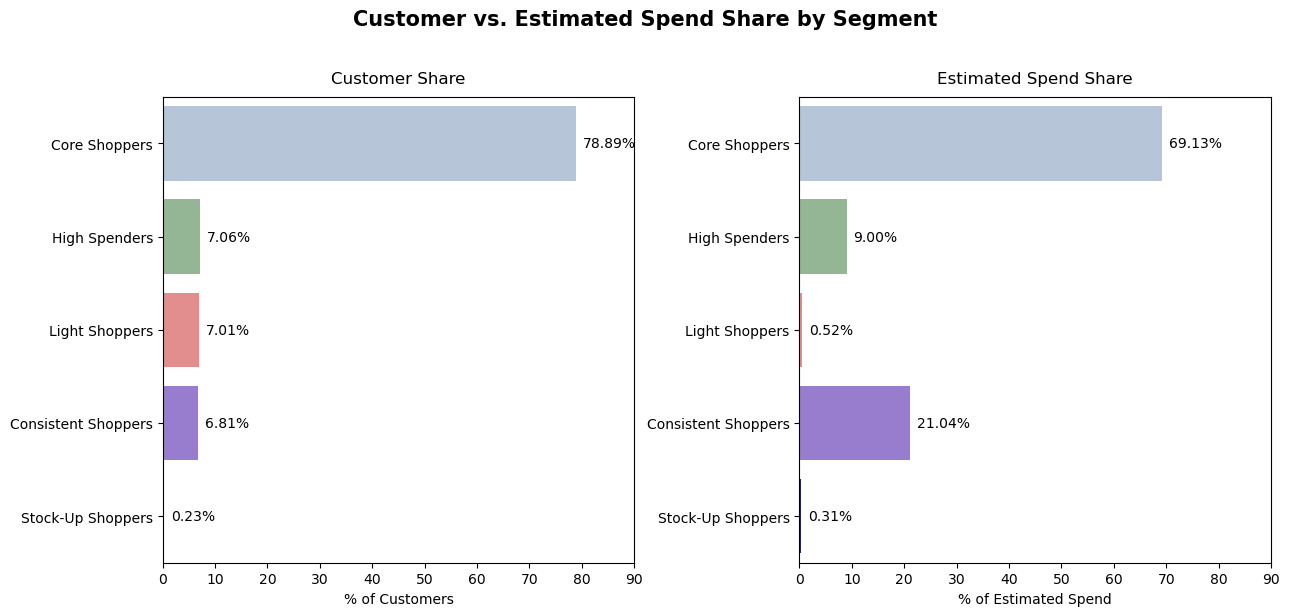

In [307]:
# Chart
fig, ax = plt.subplots(1, 2, figsize=(13, 6))

# Consistent colors
segment_colors = {
    'Core Shoppers': 'lightsteelblue',
    'Light Shoppers': 'lightcoral',
    'Consistent Shoppers': 'mediumpurple',
    'High Spenders': 'darkseagreen',
    'Stock-Up Shoppers': 'midnightblue'
}

colors = segments['Segment'].map(segment_colors).tolist()

# Customer share
segment_share_bar = sns.barplot(
    data=segments,
    y='Segment',
    x='Users (%)',
    hue='Segment',
    palette=colors,
    legend=False,
    ax=ax[0]
)

ax[0].set_title('Customer Share', fontsize=12, pad=10)
ax[0].set_xlabel('% of Customers')
ax[0].set_ylabel('')
ax[0].set_xlim(0, 90)

# Spend share
seg_revenue_share_bar = sns.barplot(
    data=segments,
    y='Segment',
    x='Revenue (%)',
    hue='Segment',
    palette=colors,
    legend=False,
    ax=ax[1]
)

ax[1].set_title('Estimated Spend Share', fontsize=12, pad=10)
ax[1].set_xlabel('% of Estimated Spend')
ax[1].set_ylabel('')
ax[1].set_xlim(0, 90)

# Add percentage labels
for a in ax:
    for container in a.containers:
        a.bar_label(
            container,
            fmt='%.2f%%',
            padding=5,
            fontsize=10
        )

plt.suptitle(
    'Customer vs. Estimated Spend Share by Segment',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.35)  # Add horizontal spacing between subplots

plt.savefig(
    os.path.join(path, '04 Insights & Visualizations', 'customer_vs_spend_share.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### <u>**Customer Value Extends Beyond Segment Size**
**High Spenders (7.1%)**, **Light Shoppers (7.0%)**, and **Consistent Shoppers (6.8%)** each represent a **similar share of the customer base**, yet contribute substantially different shares of spend. **Consistent Shoppers** generate **21.0% of estimated spend**, compared with **9.0%** from **High Spenders** and just **0.5%** from **Light Shoppers**.

> ***This contrast demonstrates why customer share alone is insufficient for evaluating segment value. Behavioral profiles reveal meaningful differences in estimated spend contribution, enabling strategies to be prioritized based on both customer behavior and business value.***.

---

## <div style = 'background-color: #c5ff96 '> <center> <font color='#003d29'>**7. Strategic Recommendations by Customer Segment**</font> </div>
**The following recommendations translate the behavioral insights from each customer segment into actionable business strategies**. While the current analysis is grounded in descriptive analytics, several recommendations identify opportunities for future predictive analytics including replenishment models, recommendation systems, and adaptive subscription programs that can be built upon the behavioral patterns uncovered throughout this notebook.



| Behavioral Segment      | Strategic Focus                    |
| ----------------------- | ---------------------------------- |
| **Light Shoppers**      | **Encourage** repeat purchasing to build consistent shopping habits.       |
| **Core Shoppers**       | **Strengthen** existing routines.       |
| **High Spenders**       | **Convert** high-value behavior into long-term engagement.      |
| **Stock-Up Shoppers** | **Reduce** friction through automation and predictive replenishment. |
| **Consistent Shoppers**         | **Recognize** and **protect** long-term value.          |

*Across customer segments, recommendations progress from creating shopping habits among low-engagement users, to strengthening and deepening routines among core customers, automating high-frequency shopping missions for stock-up shoppers, and ultimately protecting long-term value among the platform's highest-value customers.*


---

### <u> **1. Light Shoppers (7.01% of Users | 0.52% of Revenue) —  <font color='lightcoral'>Low Engagement, High Growth Potential**</u> </font>
**Behavioral Profile:** While this segment accounts for 7.0% of customers but generates only 0.52% of total revenue, they represent a **large opportunity for customer development**. Successfully increasing their engagement levels has the potential to transition these disengaged customers into routine grocery shoppers.

- **Basket Size:** They maintain extremely small baskets, **averaging 5 items or less per order.**
- **Basket Construction:** Their purchases mainly consist of **basic essentials**, over-indexing on items such as **conventional produce, milk, and water**, suggesting replenishment or top-off trips rather than comprehensive grocery orders.
- **Spend Behavior:** They fall into the `low spender` tier (**<\$44 per order**). 
- **Platform Engagement:** They exhibit `low engagement`(**5 orders or less**), indicating limited integration into the platform and increased churn risk if left unaddressed.

**Business Goal:** Transform these shoppers into repeat grocery customers by **building sustainable shopping habits** through increasing order frequency and expanding basket size.

#### <font color='forestgreen'> **<u>Strategic Recommendations:</u>** </font>
- **Full-Shop Conversion Incentives:** Encourage customers to transition from small convenience orders into larger grocery trips by offering personalized spending or basket-size thresholds based on their current shopping behavior. Promotions such as "Unlock Free Delivery at $50" or "Add 3 More Items to Unlock Savings" can encourage broader department exploration while increasing basket size.
- **Progressive Basket-Building Prompts:** Encourage larger baskets by displaying personalized progress indicators as customers build their carts. For example, "You're 2 items away from free delivery" or "Add one more essential to unlock today's offer". These real-time prompts can encourage incremental basket growth while reinforcing repeat grocery shopping behavior.
- **Essential Routine Bundles:** Use lift analysis to create "one-click" bundles centered around frequently purchased staples such as milk, water, and produce. Simplifying routine replenishment can increase basket size while helping low-engagement customers establish repeat shopping habits.
- **Personalized Re-Engagement Reminders:** Identify customers approaching their typical reorder window and trigger personalized reminders featuring previously purchased items alongside complementary essentials. Delivering these reminders before expected replenishment needs can encourage repeat ordering and reduce reliance on one-off convenience purchases.

**Logic:** (`spend_status == 'low spender'`) & (`engagement_status == 'low engagement'`) & (`avg_items_per_order <= 5`)

---

### <u>**2. Core Shoppers (78.89% of Users | 69.13 of Revenue) — <font color='steelblue'>Foundation & Behavioral Baseline**</u> </font>
**Behavioral Profile:** These customers represent the platform's **largest behavioral segment** and form the foundation of recurring grocery demand. Rather than exhibiting extreme purchasing patterns, these customers display **consistent shopping routines**.
- **Basket Size:** They maintain a median of 8 items per order, with **46.7%** of baskets concentrated between 6–14 items, suggesting a consistent but expandable grocery mission. 
- **Basket Construction:** They build their carts almost entirely around fresh items, specifically **produce, dairy, and eggs** consistent with routine household replenishment centered around fresh grocery essentials.
- **Order Frequency:** They primarily fall within the `regular shopper` segment **(10–19 days between orders)**, representing an opportunity to shift customers toward more frequent weekly engagement. 
- **Order Timing:** They favor highly routine **morning and afternoon**, suggesting established routines and predictable engagement opportunities.

**Business Goal:** Protect this foundational base while increasing customer lifetime value by **reinforcing established routines**, increasing order frequency and encouraging broader basket composition.

####  <font color='forestgreen'>**<u>Strategic Recommendations:</u>** </font>
- **Routine Shopping Shortcuts:** Capitalize on recurring shopping patterns by providing "one-click" access to customers' most frequently purchased products through shortcuts such as "Weekly Essentials" or "Fresh Produce Restock". Streamlining app navigation for routine purchases can reduce decision fatigue while encouraging faster basket completion.
- **Seasonal Basket Expansion:** Introduce seasonal collections directly into customers' routine shopping missions, highlighting relevant additions during major calendar events such as back-to-school, holidays, or seasonal transitions. Embedding these recommendations within existing shopping journets can encourage incremental purchases without requiring customers to plan a separate shopping trip.
- **Time-Aligned Nudges:** These customers consistently shop during morning and afternoon hours, so dynamically tailor the app homepage to match their typical shopping routines. Highlight frequently or recently purchased items, personalized shopping lists, and meal-planning inspiration immediately upon login, reducing search effort while reinforcing habitual purchasing behavior.
  
**Logic:** Catch-All / Default (`np.select` fallback)

---

### <u> **3. High Spenders (7.06% of Users | 9.00% of Revenue) — <font color='darkseagreen'>The Ascension Segment** </u>
**Behavioral Profile:** These customers already **generate disproportionate value**, contributing 9.00% of total revenue from just 7.06% of the user base. However, their moderate engagement indicates that they have not yet reached the platform's highest engagement tier, creating a clear opportunity for **upward mobility by deepening their relationship with the platform**.

- **Basket Size:** They build large baskets containing **15-30 items per order**, indicating they use the platform for broad grocery needs rather than small convenience trips.
- **Platform Engagement:** They currently exhibit **moderate engagement (6–19 total orders**, highlighting additional opportunities to increase platform usage and shopping frequency.
- **Income Status:** They map directly to **middle-to-high income tiers (\\$61k–\\$200k)**, suggesting greater purchasing capacity to pay a premium for convenience and timesaving features.

**Business Goal:** Increase activity levels by **converting high-value behavior into more frequent, routine engagement**.

#### <font color='forestgreen'>**<u>Strategic Recommendations:</u>**
- **Frame Rewards as Losses (Prospect Theory):** Instead of "Earn 100 points if you order this week", frame it as "You have 100 points expiring in 48 hours". Customers are more likely to avoid losing a benefit as they are to gain one.
- **Opt-Out Priority Access (Status Quo Bias):** Auto-enroll them into a premium perk like free priority delivery windows for 30 days to deepen engagement. To stop receiving it, they’d have to actively opt-out, which they are less likely to do based on the Status Quo Bias. 
- **Personalized Value Dashboard:** Highlight the value customers receive from the platform by providing personalized monthly summaries providing metrics such as time saved, favorite products reordered, delivery savings, shopping streaks, and spending trends. Making these benefits visible can reinforce the benefits they receive from being an active user.
  
**Logic**: (`spend_status == 'high spender'`) & (`avg_items_per_order.between(15, 30)`) & (`engagement_status == 'moderate engagement'`)

---

### <u>**4. Stock‑Up Shoppers (0.23% of Users | 0.31% of Revenue) — <font color='midnightblue'>Behavioral Niche** </u>
**Behavioral Profile:** Although this segment accounts for just 0.23% of customers, they **consistently place complex, high-value orders**, though infrequently. Their shopping behavior is consistent with planned **stock-up trips**, making them a strong candidate for **automation, personalization, and time-saving features** to **increase engagement through convenience rather than discounts**. 

- **Basket Size:** They maintain massive, complex carts containing a **minimum of 30+ items per order**, indicating they use the platform for substantial grocery trips rather than for small fill-in purchases.
- **Basket Construction:** Lift analysis revealed a broad product mix consisting of **organic products, specialty dairy, and pre-packaged convience items**, reflecting that they build comprehensive baskets, rather than buying in bulk or focusing on a narrow set of products. 
- **Order Frequency:** They are strictly **occasional shoppers (>= 20 days between orders)**, using the platform for monthly or multi-week stock-up trips.
- **Spend Behavior:** They fall into the `premium spender` tier **spending a minimum of \\$200 per order**, making each shopping trip highly valuable despite occurring less frequently.

**Business Goal:** Rather than encouraging larger baskets, focus on **reducing cognitive load, minimizing decision fatigue, and eliminating friction throughout their shopping journey**. Making large orders faster and easier can strengthen platform engagement while encouraging more frequent replenishment orders between major stock-up hauls.


#### <font color='forestgreen'>**<u>Strategic Recommendations:</u>**
- **Predictive Household Replenishment:** Use purchase frequency and item-level consumption cycles to predict when frequently purchased staples are likely running low and automatically generate personalized shopping lists populated with high-probability reorder items.
    - *For instance, maintain a dynamic "Household Staples" list that evolves with purchasing behavior while proactively recommending preferred substitutes during stockouts and notifying customers when their frequently purchased items return. Reducing the effort required to rebuild 30+ item carts can minimize planning time and encourage more frequent replenishment.*
- **Adaptive Subscription Programs:** Identify frequently replenished essentials with predictable reorder cycles and offer flexible subscription options for recurring purchases. Rather than relying on fixed delivery schedules, dynamically adjust replenishment timing based on each customer's actual purchasing behavior. This creates a more personalized subscription experience, reduces subscription fatigue, and reinforces long-term platform use.
- **Meal Planning Shortcuts:** Use basket affinity analysis to create "one-click" meal and planning bundles such as "5-Day School Lunch Kit" or "Weekend BBQ" meals. These bundles can simplify meal planning by reducing decision fatigue while also encouraging supplemental ordering between major stock-up trips.
  
**Logic:** (`spend_status == 'premium spender'`) & (`avg_basket_size >= 30`) & (`order_freq_status == 'occasional shopper'`)

---

### <u> **5. Consistent Shoppers (6.81% of Users | 21.04 % of Revenue) —  <font color='mediumpurple'>VIP Segment** </u>
**Behavioral Profile:** These customers are deeply integrated into the platform and represent its **most valuable customer segment**, **generating over one-fifth of total revenue** while accounting for just **6.8% of customers**.
- **Spend Behavior:** These customers spend on average **\\$44-\\$107 per order**.
- **Order Frequency:** They are highly consistent, `active shoppers` **(<10 days between orders)**, reflecting highly consistent shopping routines.
- **Platform Engagement:** They fall into `elite engagement` status placing **31+ total orders**.

**Business Goal:** Protect long-term customer value. **Rather than relying primarily on reward-based incentives, deepen their loyalty through convenience, personalization, proactive service recovery, and meaningful recognition** to reinforce their existing shopping habits.

####  <font color='forestgreen'><u>**Strategic Recommendations:**</u>
- **Recognition:** Recognize these customers based on activity milestones rather than spending thresholds. When customers reach meaningful behaviors such as order milestones, consistent monthly activity, or customer anniversaries, surprise them with occasional free items, premium delivery benefits, or exclusive experiences. These moments of recognition can reinforce their long-term loyalty without relying on continuous promotional discounts.
- **Proactive Service Recovery:** Automatically identify service failures and proactively provide appropriate recovery benefits. Rather than requiring customers to request compensation, offer credits, delivery upgrades, or priority support following negative experiences. Resolving issues before they become sources of frustration can help maintain their trust and reduce churn risk among the platform's most valuable customers.
- **Early-Access & Beta Testing:** Leverage their Elite engagement status by inviting these customers to test new app features, curated recipe-to-cart collections, and personalized shopping tools before broader release. Involving experienced customers early can generate valuable feedback while strengthening their sense of investment to the shopping experience.
- **VIP-Only Convenience Features:** Introduce premium features designed around the needs of highly engaged customers, such as preferred substitutions based on historical purchasing behavior, recurring order scheduling, and priority delivery windows. These personalized conveniences reduce shopping effort while reinforcing sustained loyalty.

**Logic:** (`spend_status == 'moderate spender'`) & (`order_freq_status == 'active shopper'`) & (`engagement_status == 'elite engagement'`)

---

## <div style = 'background-color: #c5ff96 '> <center> <font color='#003d29'>**Underutilized Behavioral Opportunities: Behavioral Insights Beyond Customer Segments**</font> </div>

While the previous section focused on long-term customer segments, **this section highlights micro-behaviors** tied to specific times, shopping missions, product preferences, and purchasing contexts. These insights complement the segmentation framework by **revealing opportunities for more targeted merchandising, personalized promotions, and timely marketing interventions that can further enhance customer engagement**.

---

### <u>**1. Evening Behavior** </u>
**To better understand the 10 PM spending spike, lift analysis of evening orders (6 PM–11:59 PM) revealed a distinct shopping pattern with customers disproportionately purchasing premium frozen desserts**. These baskets over-index on **name-brand ice creams**, **frozen yogurt**, **gelato**, and **dairy-free alternatives at higher price points**, consistent with targeted shopping missions rather than complete grocery orders.

#### <font color='forestgreen'> <u>**Strategic Recommendations:**</u>
- **Proactive Evening Engagement:** Deploy personalized notifications during the late afternoon (around 4 PM), *before* evening ordering activity begins to increase. Messaging should feature customers' preferred frozen treats or historically co-purchased items to encourage earlier cart creation and increase conversion during the evening window.
- **Contextual Frozen Category Merchandising:** Embed real-time, product suggestions within the frozen department and adjacent categories (like frozen meals). Using historical basket affinity, the platform can suggest complementary items, increasing cross-category purchases and average order value.
- **Occasion-Based Evening Bundles:** Create curated in-app collections designed around evening occasions, such as "Movie Night", "Self-Care" days, or "Wind-Down Time". These collections can make it easier for customers to shop by occasion rather than for individual products, encouraging basket expansion.
- **Dynamic Merchandising:** Dynamically feature frozen dessert collections on the homepage during evening hours. Aligning the app layout with the most relevant products can streamline product discovery and speed up conversion.

---

### <u> **2. Overnight Behavior** </u>
Order activity within the **overnight window (12 AM–5 AM)** reaches a spending peak around 4 AM, reflecting an **early-morning preparation mission** rather than late-night browsing. Baskets placed during this **4 AM surge** are primarily focused on breakfast staples and fresh, morning essentials including liquid egg whites, lactose-free milk, bottled water, spinach, and organic mushrooms. 

####  <font color='forestgreen'><u>**Strategic Recommendations:**</u>
- **Morning Routine Recommendations:** Leverage basket affinity analysis to recommend complementary products commonly associated with breakfast and morning preparation. Aligning recommendations with customers' observed shopping mission can encourage modest basket expansion while preserving the speed and convenience of these trips.
     - *For example, turmeric root was identified as a high-lift product (lift = 1.67) and ranked among the top 10 products by spend impact ($835.73). Customers purchasing turmeric could receive tailored recommendations for complementary ingredients commonly associated with morning wellness routines, such as ginger or citrus fruits. These suggestions can expand baskets naturally while remaining relevant to customers' existing shopping patterns.*
- **Express Morning Checkout:** Since these orders are typically task-oriented, streamline the checkout experience by surfacing recently purchased items, saved payment methods, and preferred delivery windows. Reducing the number of steps required to complete an order can better support customers shopping under possible time constraints.

---

### <u>**3. Premium vs. Low Spend Customer Purchasing Preferences** </u>
The product mix of Premium and Low Spend customers reveals distinct shopping patterns that extend beyond differences in spending alone:
- **Premium Spenders** consistently **over-index** on **organic produce**, **specialty dairy**, **deli items**, and **convenience-oriented products**. Since they already build large, comprehensive baskets and **spend a minimum of \\$200 per order** strategies should focus on **premium trade-ups** and **cross-category product discovery**.
- **Nearly 46% of Low Spenders** fall in to the **low income tier (earning \\$60k or less)**, with **30%** of this segment being **occasional shoppers (20+ days between orders)**. These findings combined with their **small basket sizes (~4 items)** may reflect budget-conscious shopping behavior rather than a lack of platform engagement. Based on lift analysis, these customers **focus on buying the essentials** and strategies that align with their existing shopping habits may be more effective than trying to create new behaviors. 

#### <font color='forestgreen'> <u>**Strategic Recommendations:** </u>
- **Premium Customers: Reinforce High-Value Shopping Behavior**
    - **Cross-Category Discovery (Up-Selling):** Deploy cross-category recommendations and curated seasonal collections (such as pairing artisanal cheeses with specialty deli items or organic produce) to encourage incremental trade-ups and deepen their value.
- **Low-Spend Customers: Increase Engagement and Basket Size**
    - **Habit-Aligned Basket Building:** Leverage their reliance on basic essentials (milk, water, and produce) through low-friction "Buy It Again" prompts and automated refill reminders to encourage repeat orders.
    - **Value-First Basket Building (Affordable Bundle Thresholds):** Shift from high spending thresholds to accessible, micro-tier incentives that reward small basket growth without pushing potential customer constraints. Highlight budget-friendly store brands and introduce lower-barrier thresholds like "\\$3 off orders over \\$25" or "Free delivery when adding 2 essential staples" to help them stretch their grocery dollars.

---

### <u>**4. Friday Transition Behavior**</u>
**Friday shopping behavior marks a clear transition from weekday convience purchasing to weekend meal preparation**. Although Saturday and Sunday are the highest volume days, Friday generates the **largest average basket size (~16 items per order)**, a **7.3% increase over the weekday average**.

Spend impact analysis shows that **fresh cooking ingredients including limes, lemons, garlic, ground beef, butter, potatoes, sour cream, and more generate the greatest incremental Friday spend**, while lift analysis reveals over-indexing in **common grilling ingredients, snacks, and gathering-related items**. Together, these patterns suggest that customers are **proactively preparing for weekend meals and social occasions in advance**.

#### <font color='forestgreen'> <u>**Strategic Recommendations:**</u>
- **Weekend Mode Personalization:** Transition the shopping experience beginning Thursday evening by showcasing weekend-oriented content such as grilling collections, meal planning inspiration, entertaining bundles, and seasonal recipes. Prioritize high-performing weekend products to align the app experience with customers’ shift toward preparation and planning behavior *before* the weekend begins.
- **Weekend Planning Assistance:** Starting Thursday evening, surface personalized meal inspiration, shopping checklists, and entertaining suggestions based on each customer's historical Friday purchasing patterns. Helping them organize larger weekend orders can reduce their planning effort while encouraging more complete baskets.
- **Weekend Entertaining Collections:** Build curated Friday shopping collections based on high-lift products such as chipotle peppers in adobo sauce, hot dog buns, beef short ribs, potato chips, and French onion dip mix. Pair these with complementary ingredients and hosting essentials to simplify weekend planning while increasing cross-category exploration and basket size.

---

## <div style = 'background-color: lavender '> <center> <font color='darkblue'>**8. Business Takeaways**</font> </div>
**The greatest opportunity is not simply encouraging customers to spend more, but understanding how different customers shop and designing personalized experiences that reinforce those behaviors over time.**</br>
- **Customer segments** identify ***who*** should receive different engagement strategies.
-  **Micro-behaviors** identify ***when*** and ***how*** those strategies can be delivered most effectively.

**This analysis demonstrates that grocery shopping behavior extends beyond traditional purchasing metrics such as order frequency and average spend.** By combining rule-based segmentation with temporal shopping patterns, order-level behavior, basket size, and product-lift analyses, **distinct customer groups and shopping missions emerged that support more targeted business strategies**.

**Rather than applying a single marketing approach across the entire customer base, the findings suggest opportunities to personalize the customer experience based on both long-term behavioral patterns (customer segments) and contextual shopping insights (micro-behavioral opportunities)**. Together, these insights provide a framework for supporting customer lifetime value growth through habit formation, tailored merchandising, friction reduction, and more relevant shopping experiences aligned with each customer's behavioral profile.

## <div style = 'background-color: lavender '> <center> <font color='darkblue'>**Limitations**</font> </div>
*The dataset reflects shopping behavior from active Instacart users during the 2017 period. As a result, the analysis focuses on behavioral patterns among existing customers rather than long-term acquisition or retention trends.*

- **Lack of Margin/Cost Data:** The analysis relies strictly on the `price` column to calculate several variables including gross `total_order_spend` and spend impact. As a result, high-spend segments (like Consistent Shoppers) and spend calculations should be interpreted as indicators of gross customer value rather than profitability, since cost and margin data are not included in this dataset.
- **Dynamic Pricing and Spend Threshold Limitations:** Product prices may change over time due to inflation, promotions, or dynamic pricing. Since several behavioral classifications rely on static spend thresholds, customers may be misclassified if spending changes reflect price shifts rather than changes in purchasing behavior.
- **No Prior Marketing Context:** This data does not include records for historical promotions such as push notifications or discount codes, which may influence observed behaviors. For example, if previous promotions included weekly Friday discounts, that could inflate Friday’s average spend and mimic weekend‑prep behavior.
- **Behavioral Snapshots:** This segmentation looks at a static window of user behavior. It does not track how users may evolve over time, such as how a Core Shopper can evolve into a Consistent Shopper for instance, nor does it capture how seasonal effects may influence purchasing patterns.
- **Absence of Qualitative Context:** The dataset tells us *what* users are buying and *when*, but lacks qualitative context (user surveys or customer support logs) that would help explain *why* certain behaviors occur, such as disengagement among Light Shoppers users. 
- **Causal Validation:** This analysis identifies behavioral patterns and opportunities but does not prove that recommended interventions will increase engagement or basket size. Further analysis such as A/B testing would be needed to measure the actual impact of personalized strategies.


## <div style = 'background-color: lavender '> <center> <font color='darkblue'>**Recommended Next Steps & Future Analytical Work**</font> </div>
 
The behavioral segments developed in this analysis create opportunities for deeper analytics and more personalized customer experiences. Consider focusing future work on validating these segments over time, building predictive models, applying these insights to improve customer experiences, and measuring business impact.

### <u>**Validate & Test:**
- Monitor segment stability over time and track customer movement between segments.
- Conduct customer surveys or interviews to gain an understanding of the motivations behind the observed purchasing patterns identified in this analysis.
- Evaluate the effectiveness of segment-specific promotions and personalization strategies by running controlled A/B tests.
- ***Example:** Partner with product teams to test a personalized stock-up shopping experience for the Stock-Up Shoppers, measuring impact on basket completion, order frequency, and customer retention.*
  
### <u>**Predict & Personalize:**
- Develop churn, reorder timing, and customer lifetime value models.
- Predict changes in customer engagement and identify customers likely to move between behavioral profiles.
- ***Example:** Build reorder prediction models that estimate household replenishment cycles using historical purchase intervals. This could enable automated shopping lists and more timely restock reminders for customers in the Stock-Up segment for instance.*
- ***Example:** Identify early behavioral indicators of churn, identifying users before their engagement declines (into segemnts like the At-Risk Replenishers group) or their basket sizes decrease.*
    
### <u> **Implement & Expand:**
- Integrate behavioral segment labels into personalization systems, recommendation tools, and marketing workflows.
- Combine behavioral segments with basket affinity analysis to deliver more relevant product recommendations, cross-selling opportunities, and personalized promotions.
- Incorporate additional customer attributes such as geography, promotion responsiveness, and seasonality to further refine behavioral segments and targeting strategies.
- Continuously monitor and update the segmentation framework as new customer behavior and purchasing data becomes available.
- ***Example:** Customers within the same behavioral segment may have different needs based on geography, seasonality, or local preferences. Incorporating this contextual data could further personalize recommendations and improve product relevance.*

> **Ultimately, customer segmentation is most valuable when it becomes an operational decision-making tool. By combining behavioral insights with predictive analytics and personalized promotions, Instacart can move from *understanding* customer behavior to *anticipating* customer needs to proactively deliver more relevant, data-driven experiences.**